In [1]:
source(here::here("settings.R"))
source(here::here("load_archr.R"))

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)
addArchRVerbose(verbose = FALSE)


Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [43]:
keep_cells = ArchRProject@cellColData[ArchRProject@cellColData$stage == 'GD9',]$cell

In [44]:
addArchRThreads(12)

Setting default number of Parallel threads to 12.



In [45]:
ArchRProject = subsetArchRProject(
  ArchRProj = ArchRProject,
  cells = keep_cells,
  outputDirectory = "GD9",
  dropCells = TRUE,
  logFile = NULL,
  threads = getArchRThreads(),
  force = TRUE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/GD9

Copying Arrow Files...

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 12): Annotations

Copying Other Files (2 of 12): Background-Peaks.rds

Copying Other Files (3 of 12): GroupBigWigs

Copying Other Files (4 of 12): GroupCoverages

Copying Other Files (5 of 12): IterativeLSI

Copying Other Files (6 of 12): LSI

Copying Other Files (7 of 12): Peak2GeneLinks

Copying Other Files (8 of 12): PeakCalls

Copying Other Files (9 of 12): PeakMatrix

Copying Other Files (10 of 12): Plots

Copying Other Files (11 of 12): RNAIntegration

Copying Other Files (12 of 12): TileMatrix

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   

In [2]:
io$archR.directory = file.path(io$basedir, 'ArchR/GD9')
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [50]:
file.path(io$output.directory, 'Peak_calling/Peakset.rds')

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/Peak_calling/Peakset.rds"

In [46]:
old_peaks.gr = getPeakSet(ArchRProject)

In [51]:
saveRDS(old_peaks.gr, file.path(io$output.directory, 'Peak_calling/Peakset.rds'))

In [52]:
peaks = fread("/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/data/raw/Combined/BGRGP8/outs/peak_annotation.tsv")

In [61]:
peaks.gr = GRanges(
    seqnames = Rle(paste0('chr',peaks$chrom)),
    ranges = IRanges(peaks$start, end = peaks$end, names = peaks$gene))

In [67]:
old_peaks.gr[,0]

GRanges object with 286718 ranges and 0 metadata columns:
      seqnames              ranges strand
         <Rle>           <IRanges>  <Rle>
   C7     chr1             105-705      *
   C7     chr1            951-1551      *
   C7     chr1           1695-2295      *
  C20     chr1           2623-3223      *
  C20     chr1           3226-3826      *
  ...      ...                 ...    ...
  C23     chrX 111564571-111565171      *
  C20     chrX 111629848-111630448      *
  C17     chrX 111631612-111632212      *
  C18     chrX 111667008-111667608      *
   C7     chrX 111678796-111679396      *
  -------
  seqinfo: 22 sequences from an unspecified genome; no seqlengths

In [66]:
peaks.gr 

GRanges object with 79088 ranges and 0 metadata columns:
                     seqnames              ranges strand
                        <Rle>           <IRanges>  <Rle>
               WDR31     chr1         11172-12076      *
               WDR31     chr1         15334-16238      *
               WDR31     chr1         25245-26132      *
               WDR31     chr1         30156-31076      *
               WDR31     chr1         35426-36322      *
                 ...      ...                 ...    ...
  ENSOCUG00000029751     chrX 111524177-111524925      *
  ENSOCUG00000029751     chrX 111539961-111540886      *
              GPR101     chrX 111629708-111630492      *
              GPR101     chrX 111631575-111632265      *
              GPR101     chrX 111666913-111667819      *
  -------
  seqinfo: 22 sequences from an unspecified genome; no seqlengths

In [81]:
addArchRThreads(12)

Setting default number of Parallel threads to 12.



In [69]:
ArchRProject = addPeakSet(
  ArchRProj = ArchRProject,
  peakSet = peaks.gr, 
  force=TRUE)

In [15]:
ArchRProject <- addPeakMatrix(ArchRProject)

Overriding previous entry for ReadsInPeaks

Overriding previous entry for FRIP



In [14]:
getAvailableMatrices(ArchRProject)

[1] "GeneIntegrationMatrix_PeakMatrix" "GeneIntegrationMatrix_TileMatrix"
[3] "GeneScoreMatrix"                  "MotifMatrix"                     
[5] "PeakMatrix"                       "TileMatrix"

# Try on whole dataset with 35 dim 45000 features

In [16]:
dim_redu = function(dims, features){
# Iterative LSI: two iterations
ArchRProject <- addIterativeLSI(
  ArchRProj = ArchRProject,
  useMatrix = 'PeakMatrix', 
  name = 'LSI', 
  dimsToUse = 1:dims,
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
  saveIterations = FALSE,
  varFeatures = features, 
  force = TRUE, verbose=FALSE
)

# Run UMAP
ArchRProject <- addUMAP(
  ArchRProj = ArchRProject, 
  reducedDims = 'LSI',
  name = "UMAP_PeakMatrix",
  metric = "cosine",
  nNeighbors = 25, 
  minDist = 0.3, 
  seed = 45,
  saveModel = FALSE,
  force = TRUE, verbose=FALSE
)

p = plotEmbedding(ArchRProject, 
'UMAP_PeakMatrix', 
colorBy = "cellColData", 
name = 'celltype_manual')
    print(p)
}

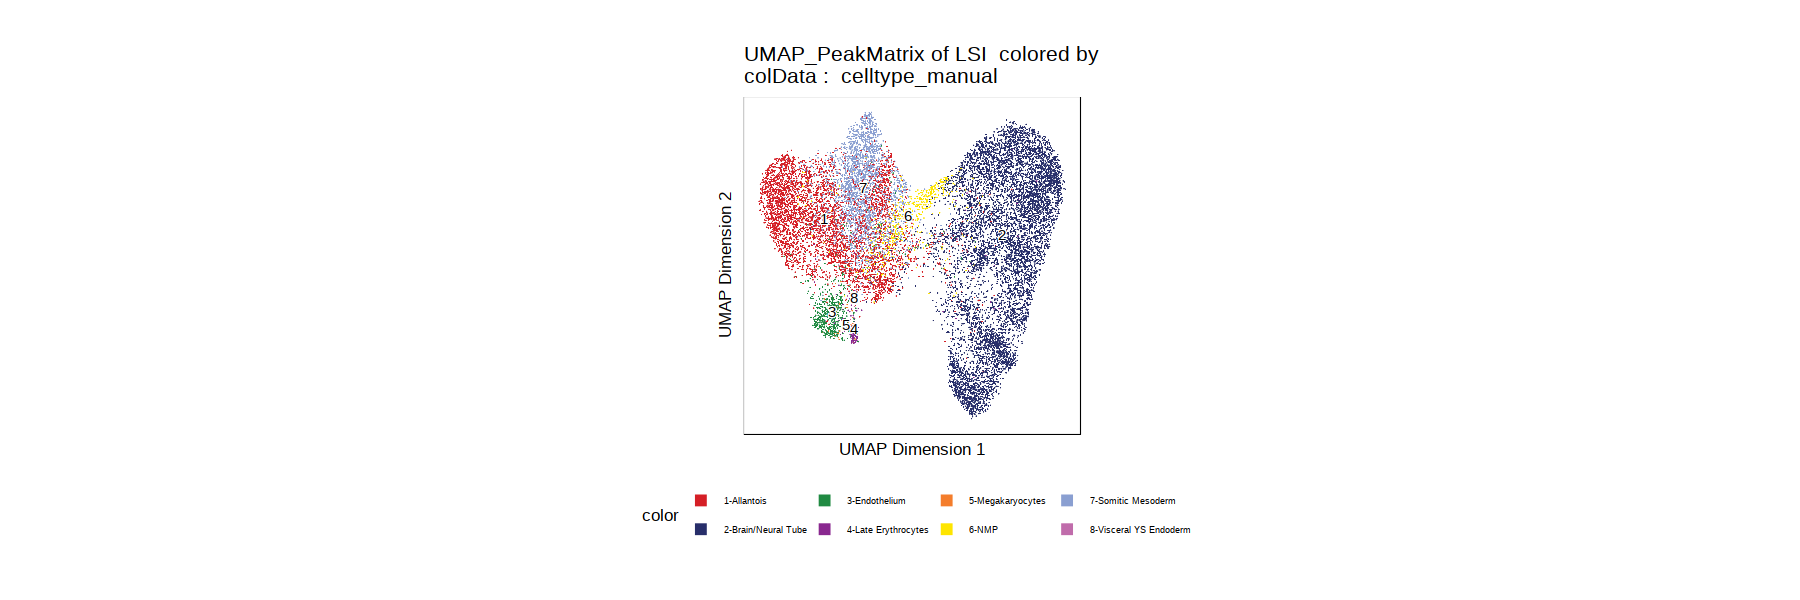

In [82]:
dim_redu(15, 2500)

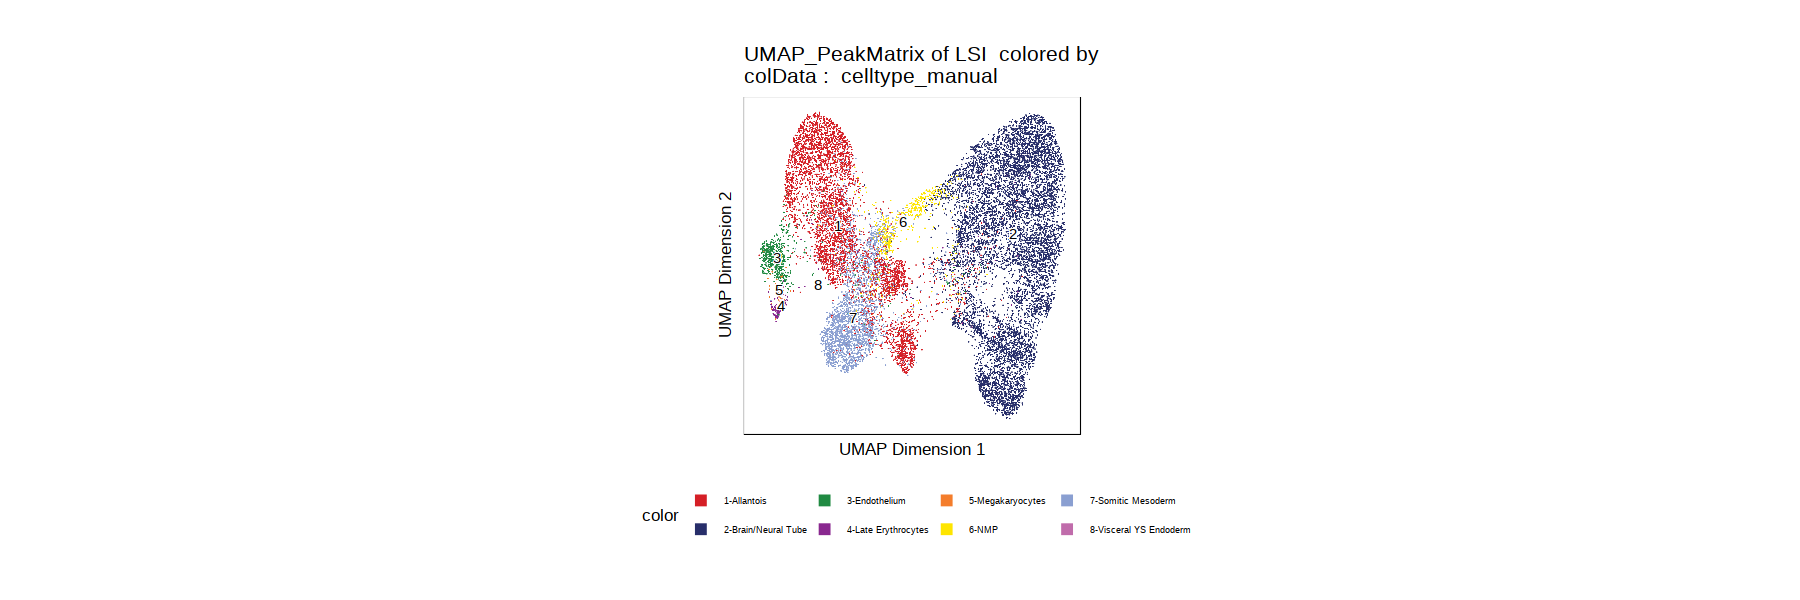

In [83]:
dim_redu(15, 4000)

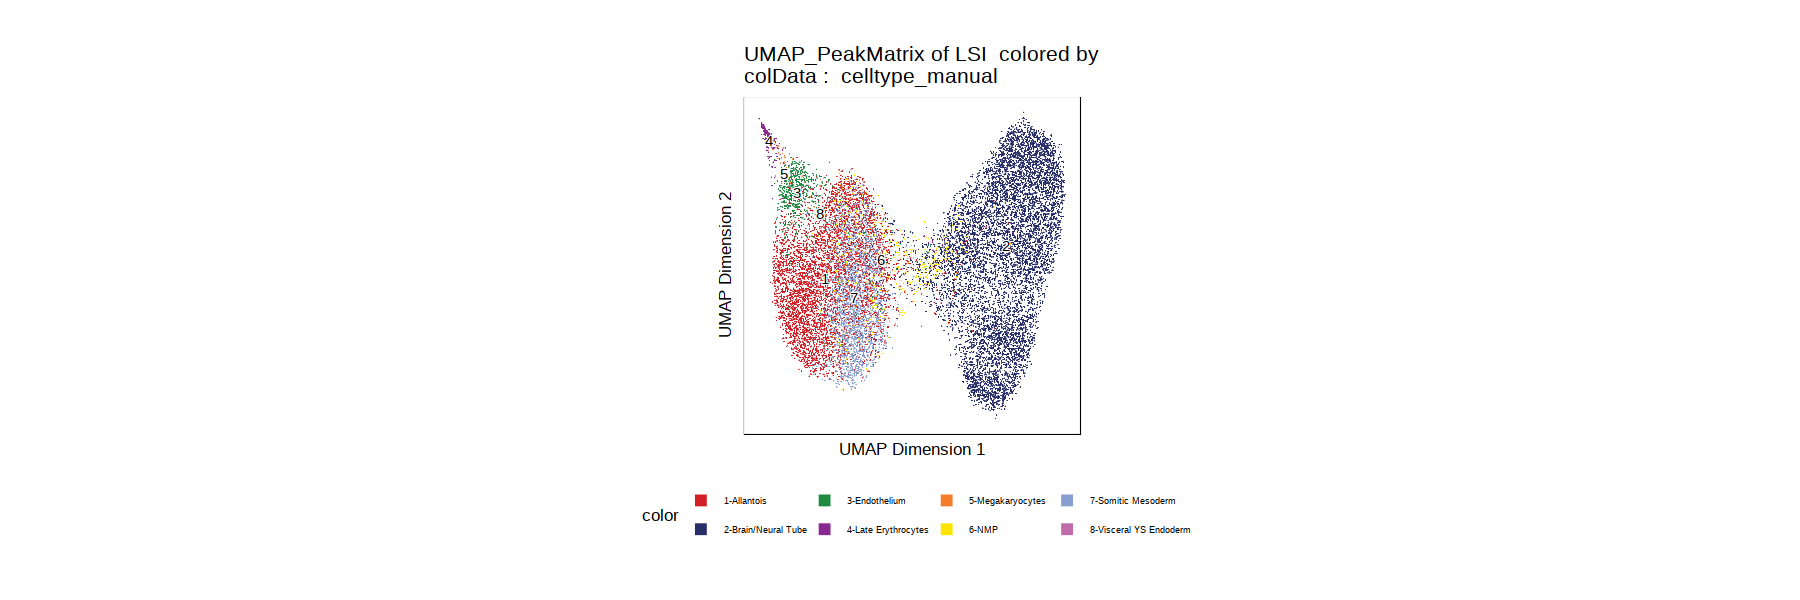

In [84]:
dim_redu(25, 2500)

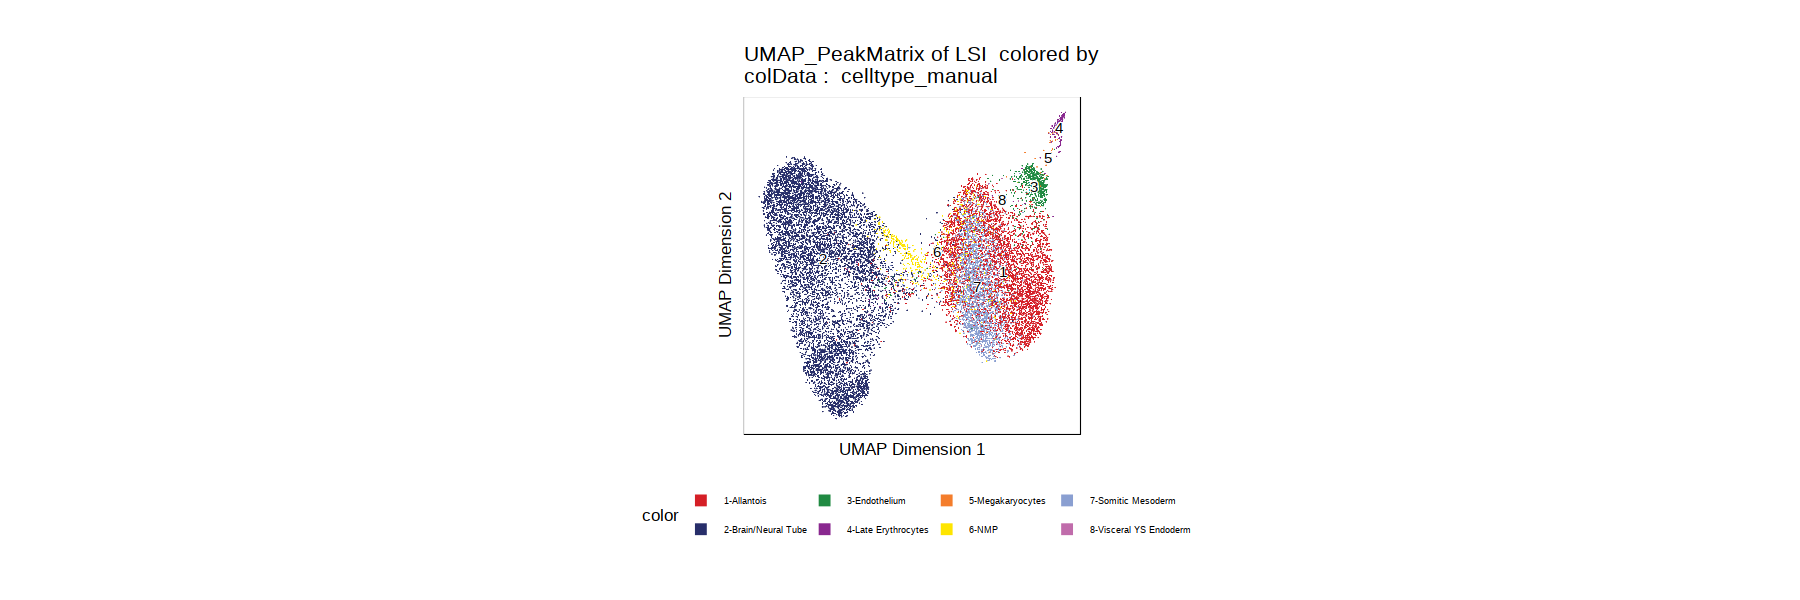

In [85]:
dim_redu(25, 4000)

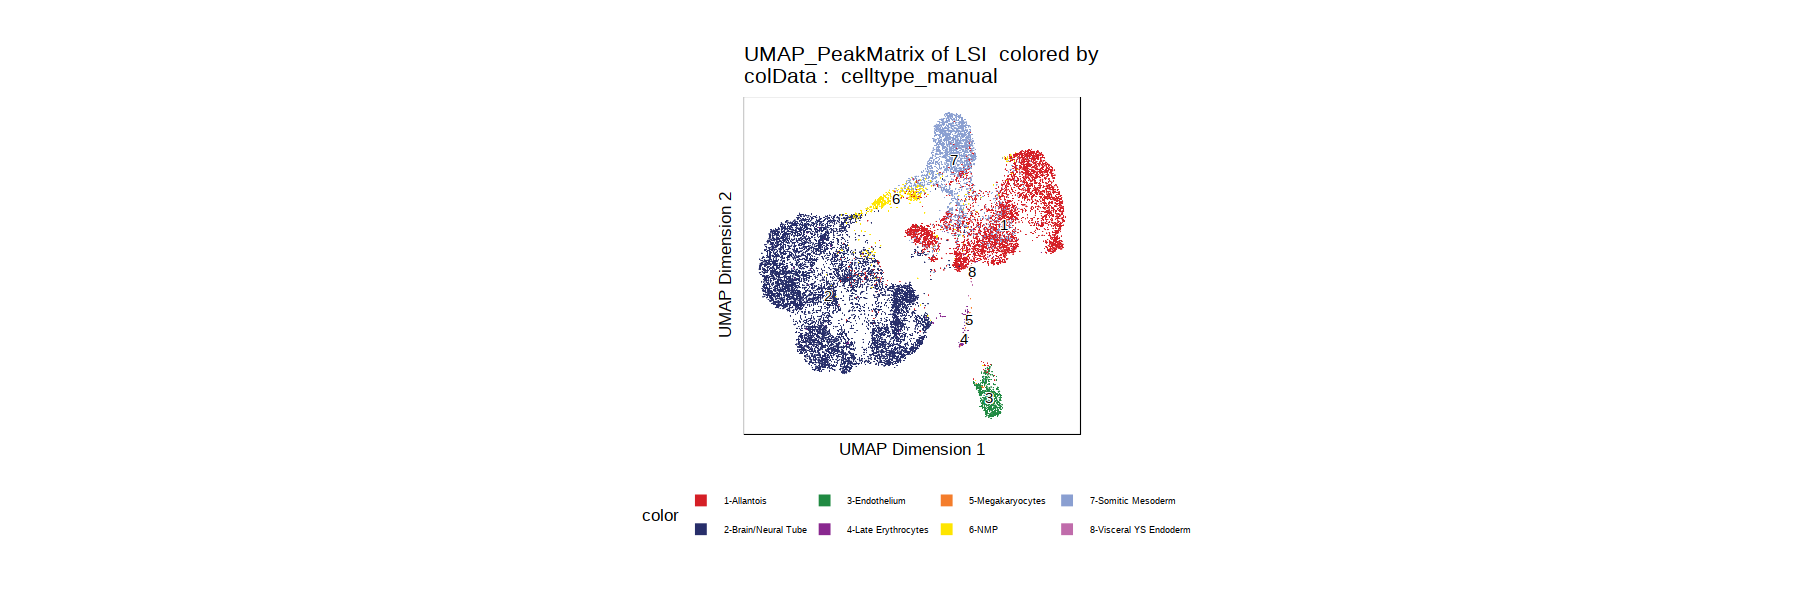

In [86]:
dim_redu(15, 25000)

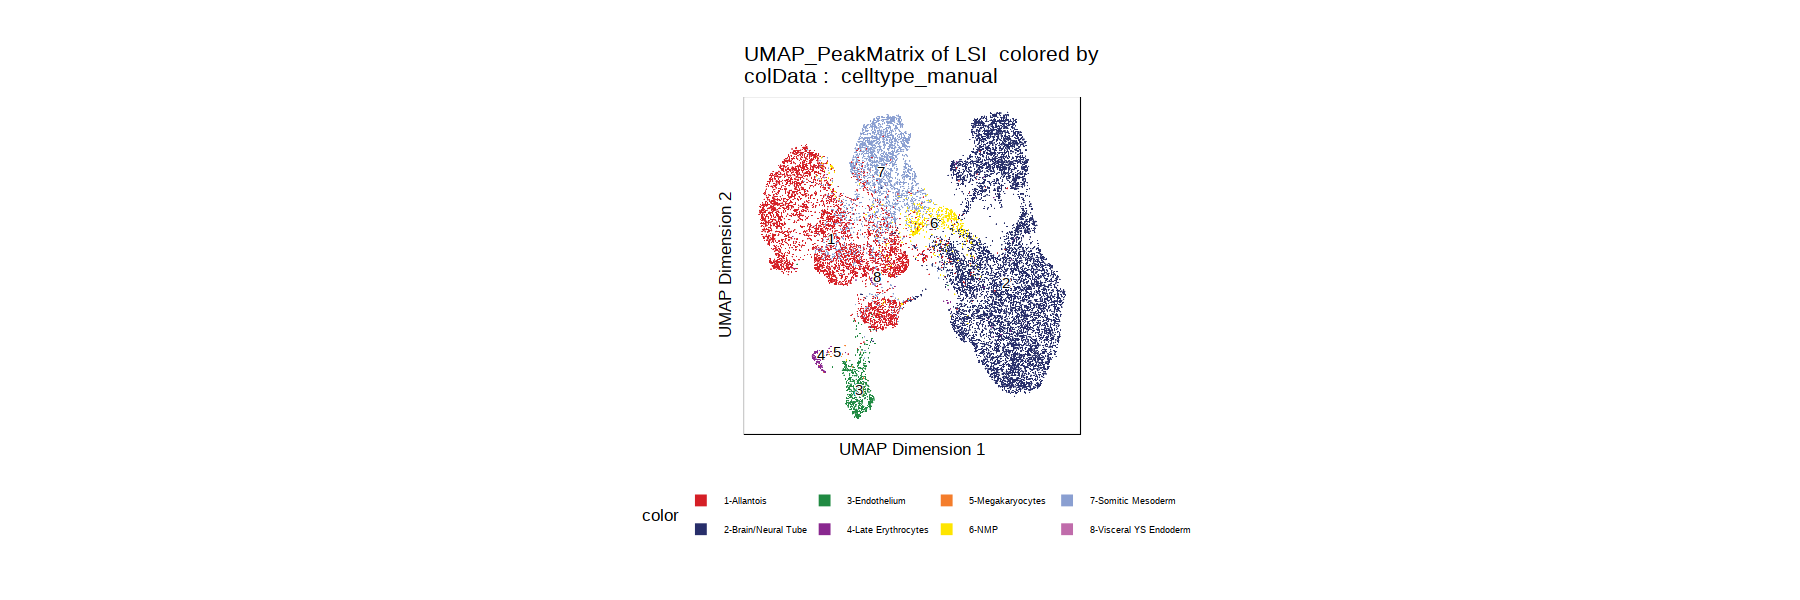

In [88]:
dim_redu(10, 25000)

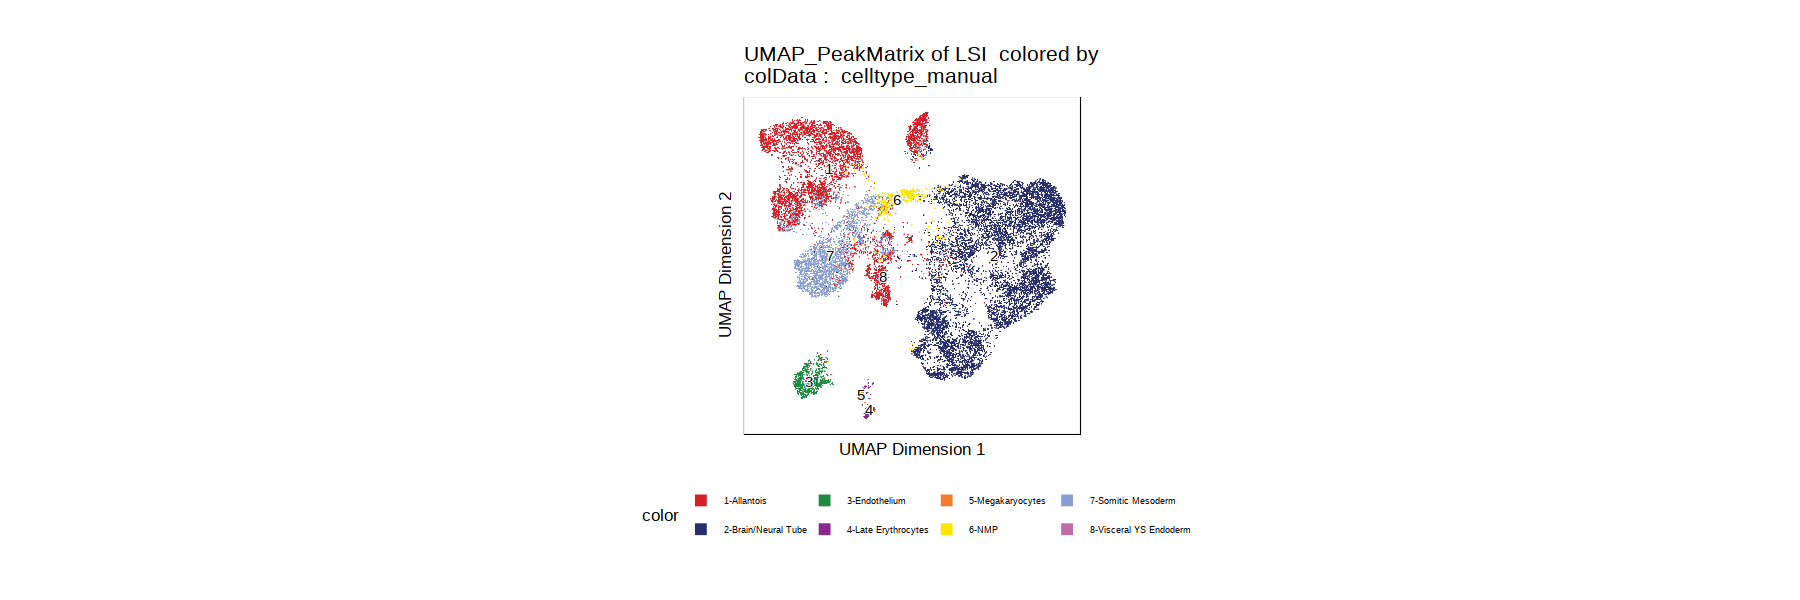

In [89]:
dim_redu(15, 45000)

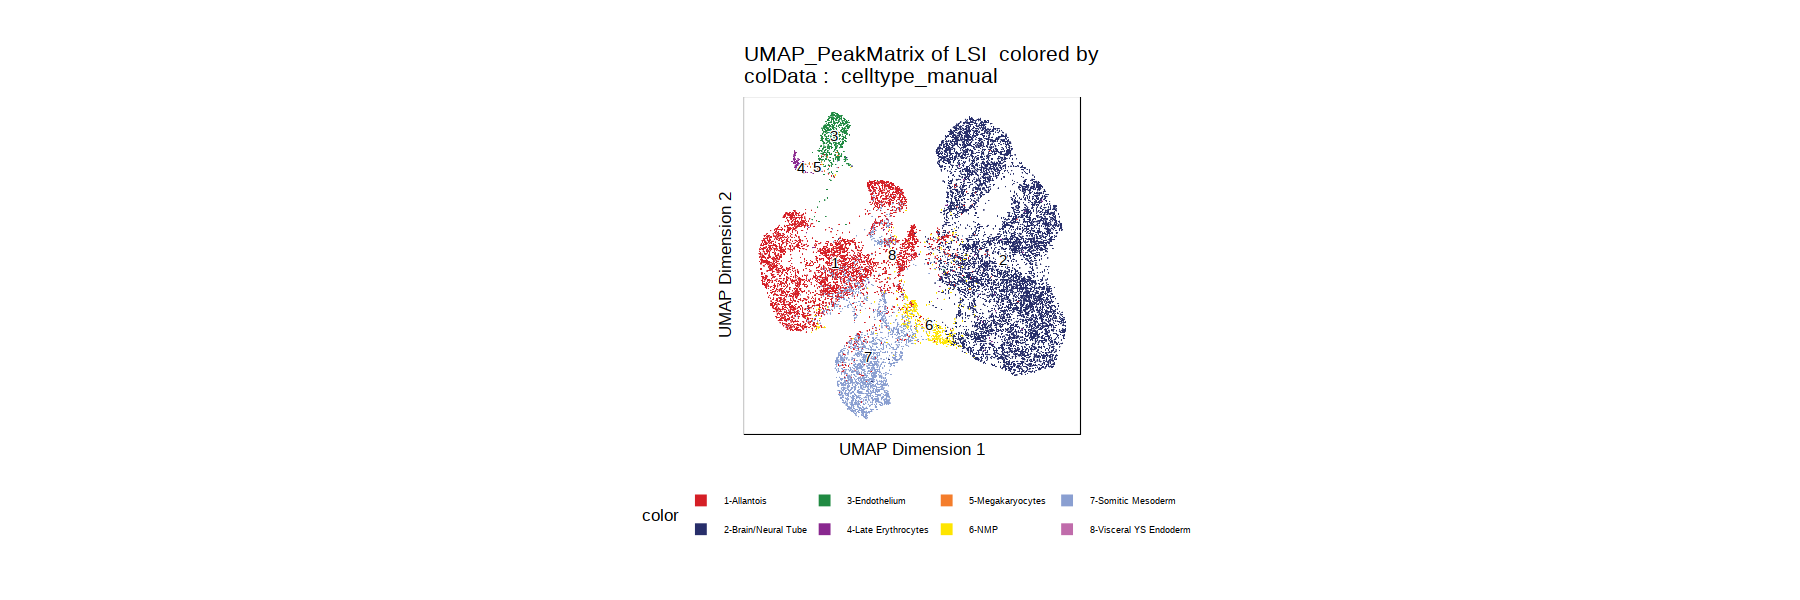

In [90]:
dim_redu(10, 45000)

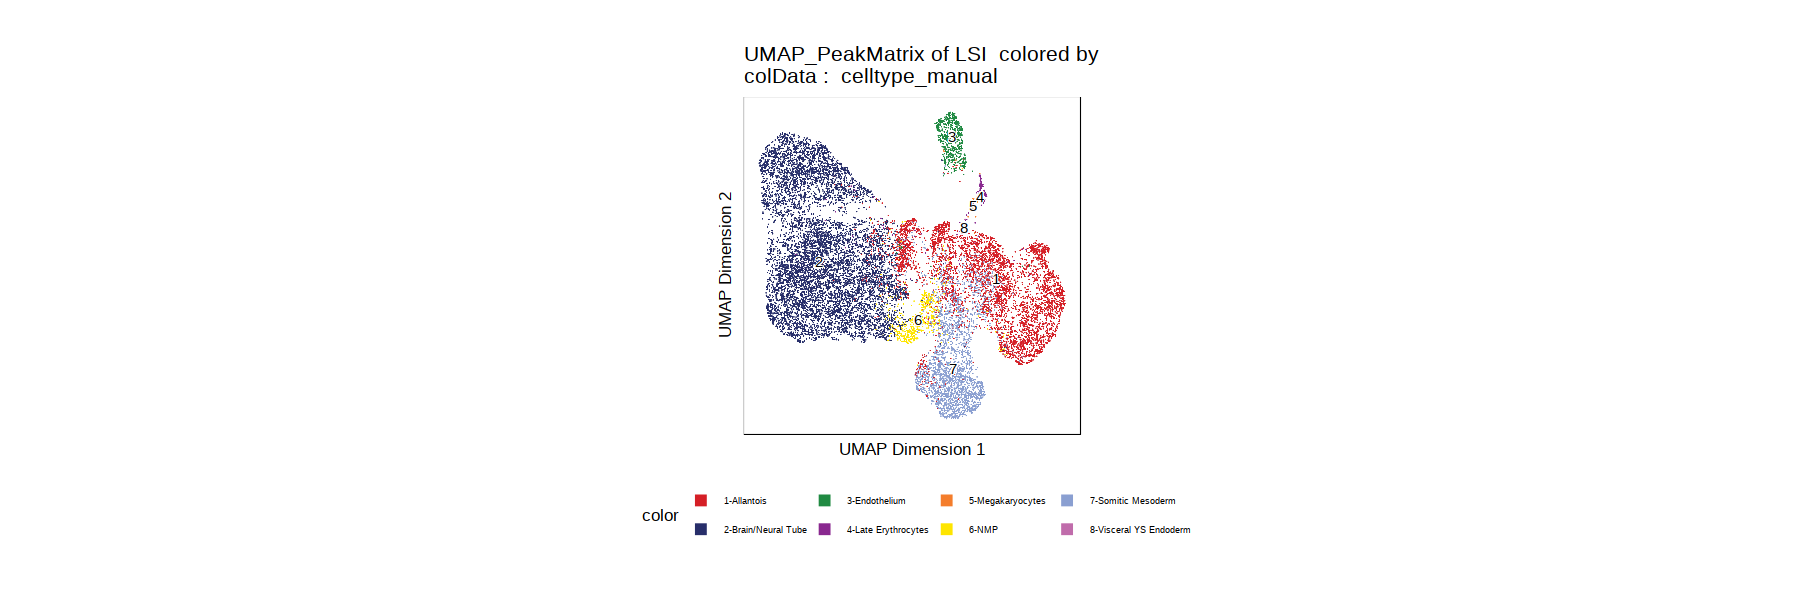

In [91]:
dim_redu(8, 25000)

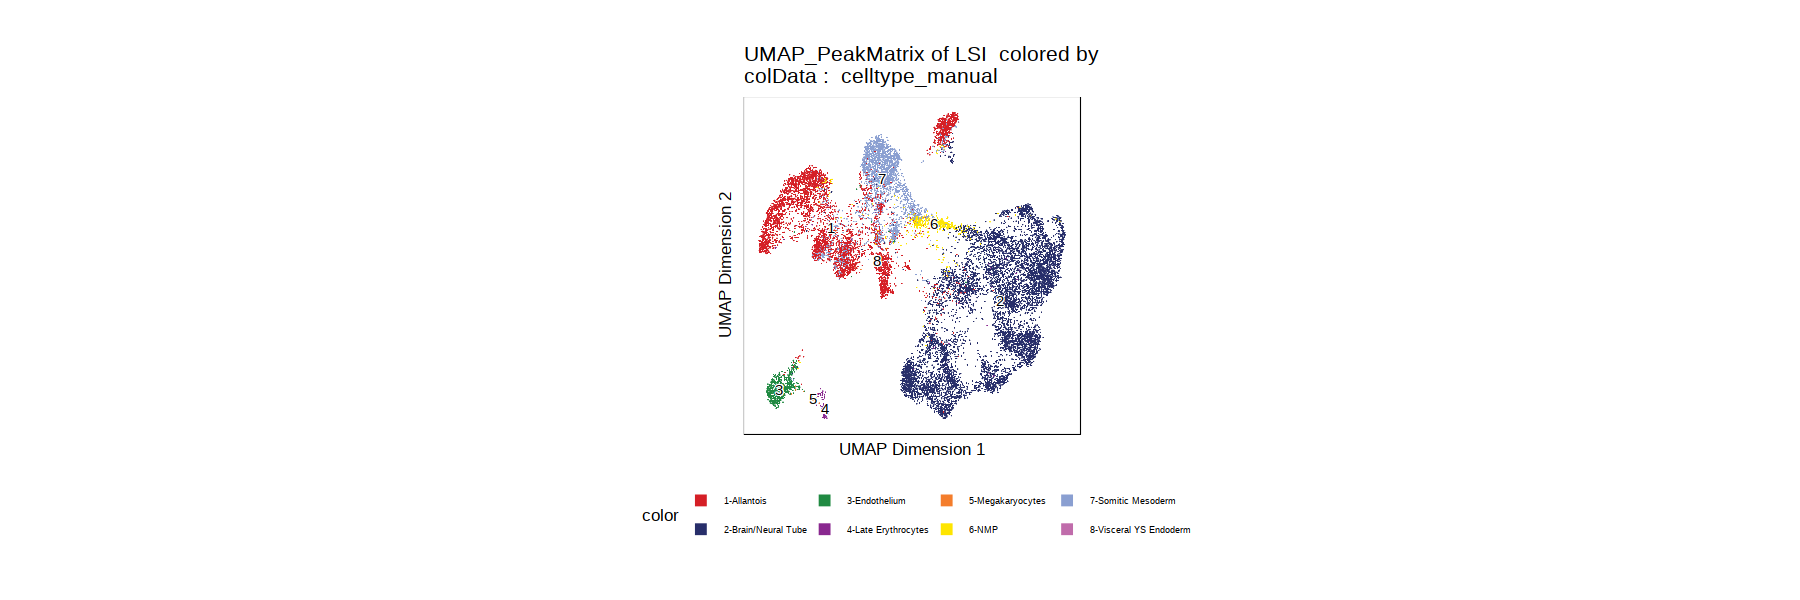

In [92]:
dim_redu(25, 45000)

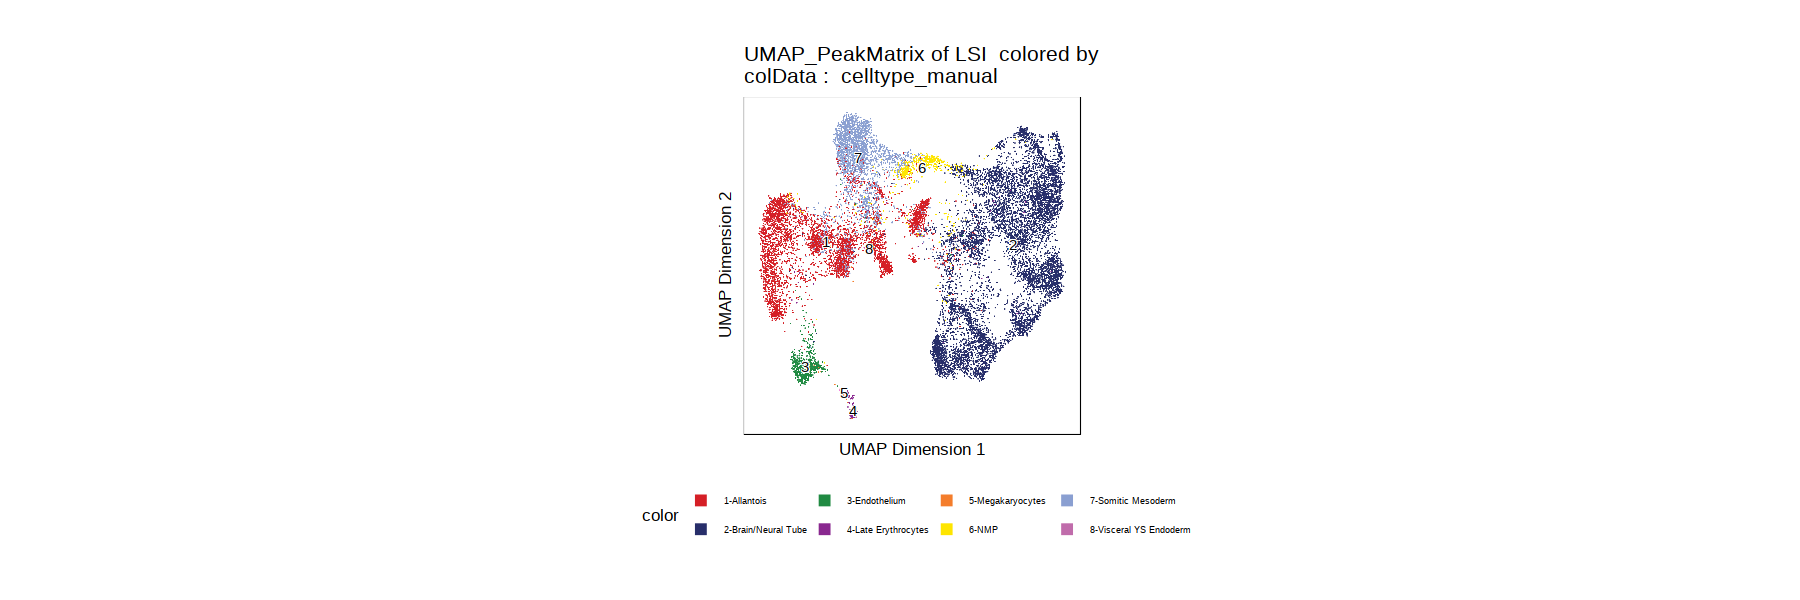

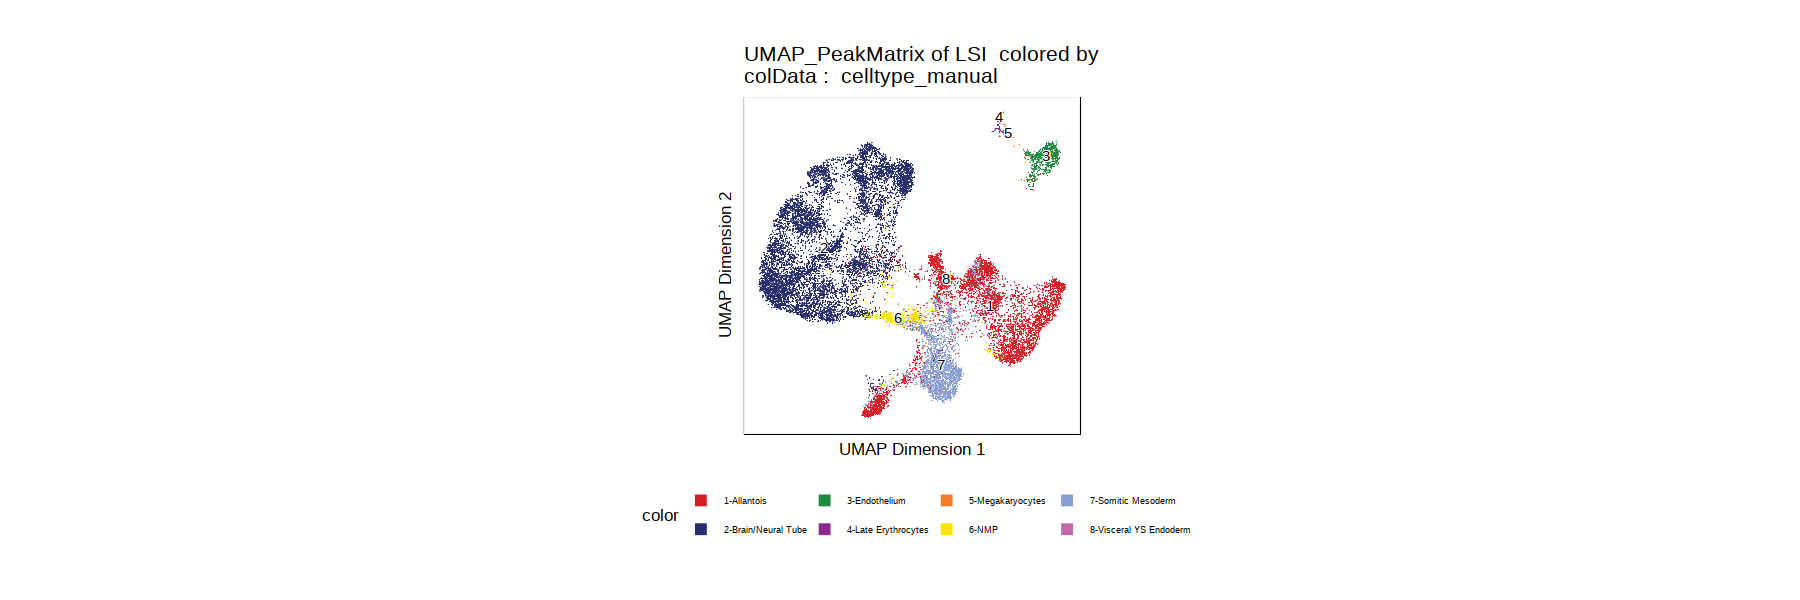

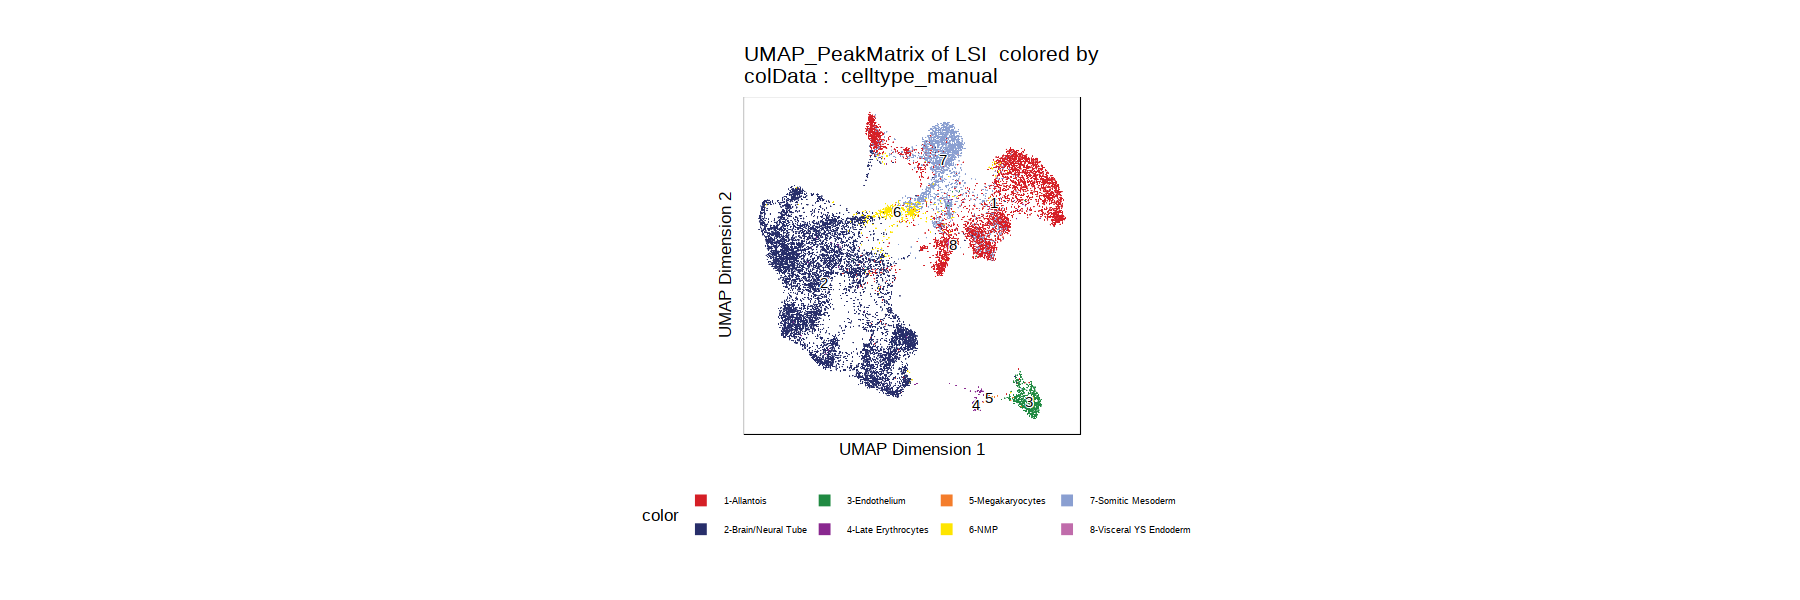

In [95]:
dim_redu(25, 30000)
dim_redu(25, 35000)
dim_redu(25, 40000)

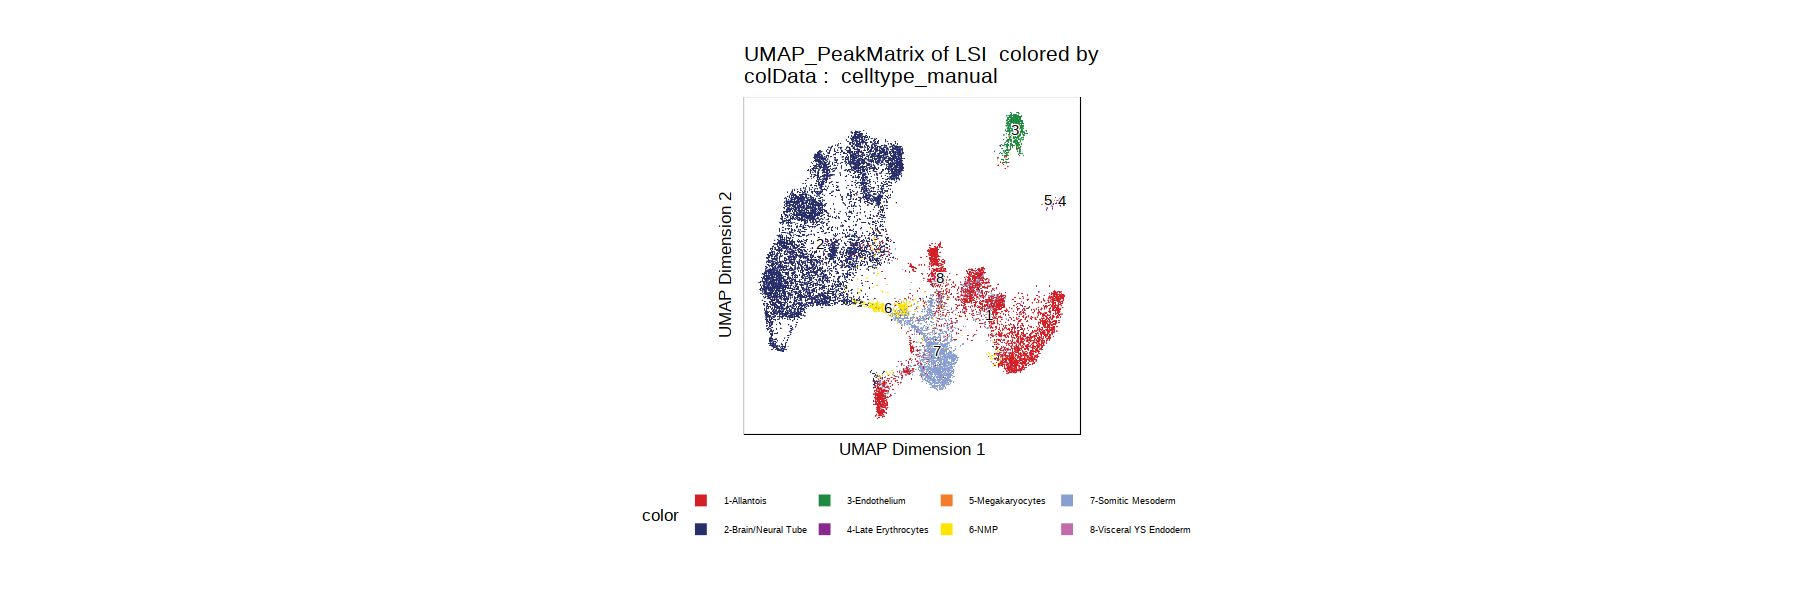

In [96]:
dim_redu(30, 40000)

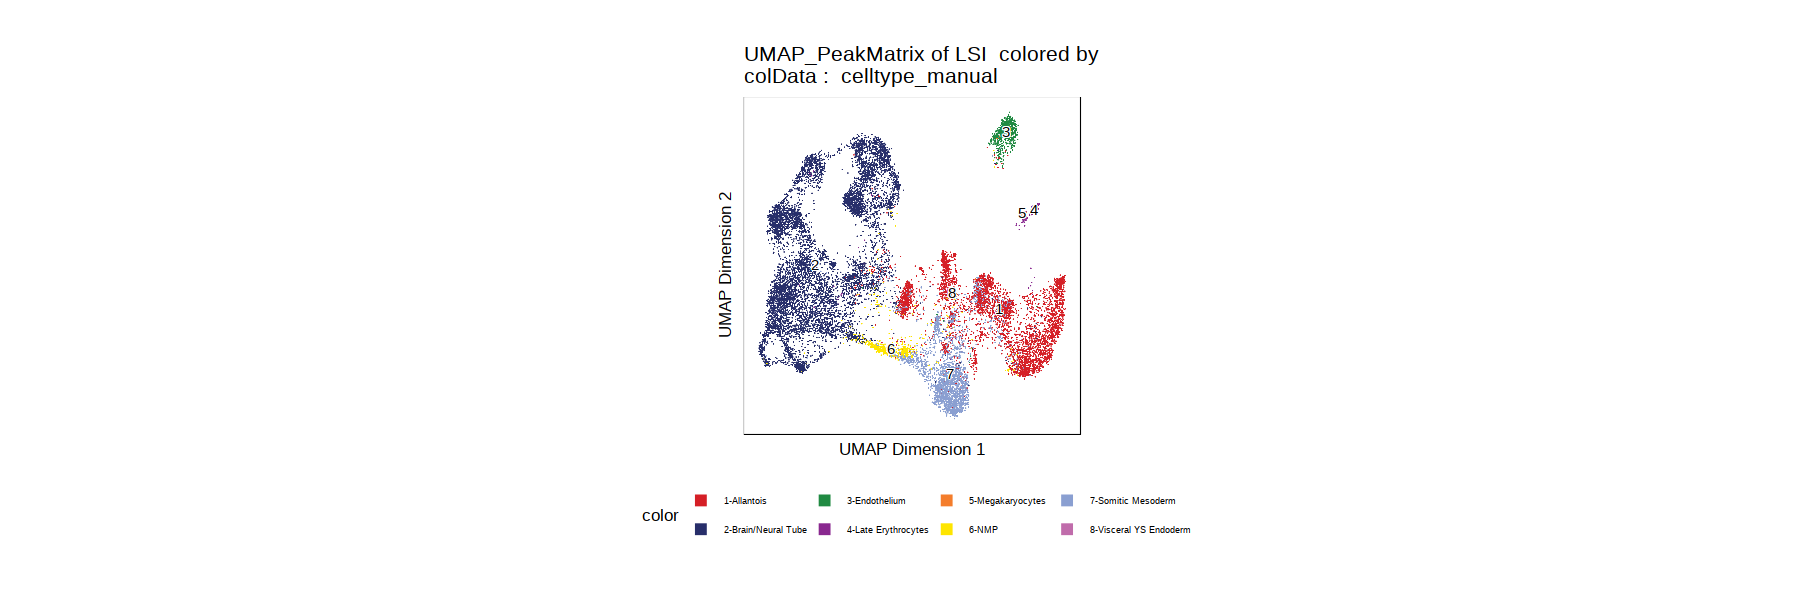

In [93]:
dim_redu(35, 45000)# <---- top option 

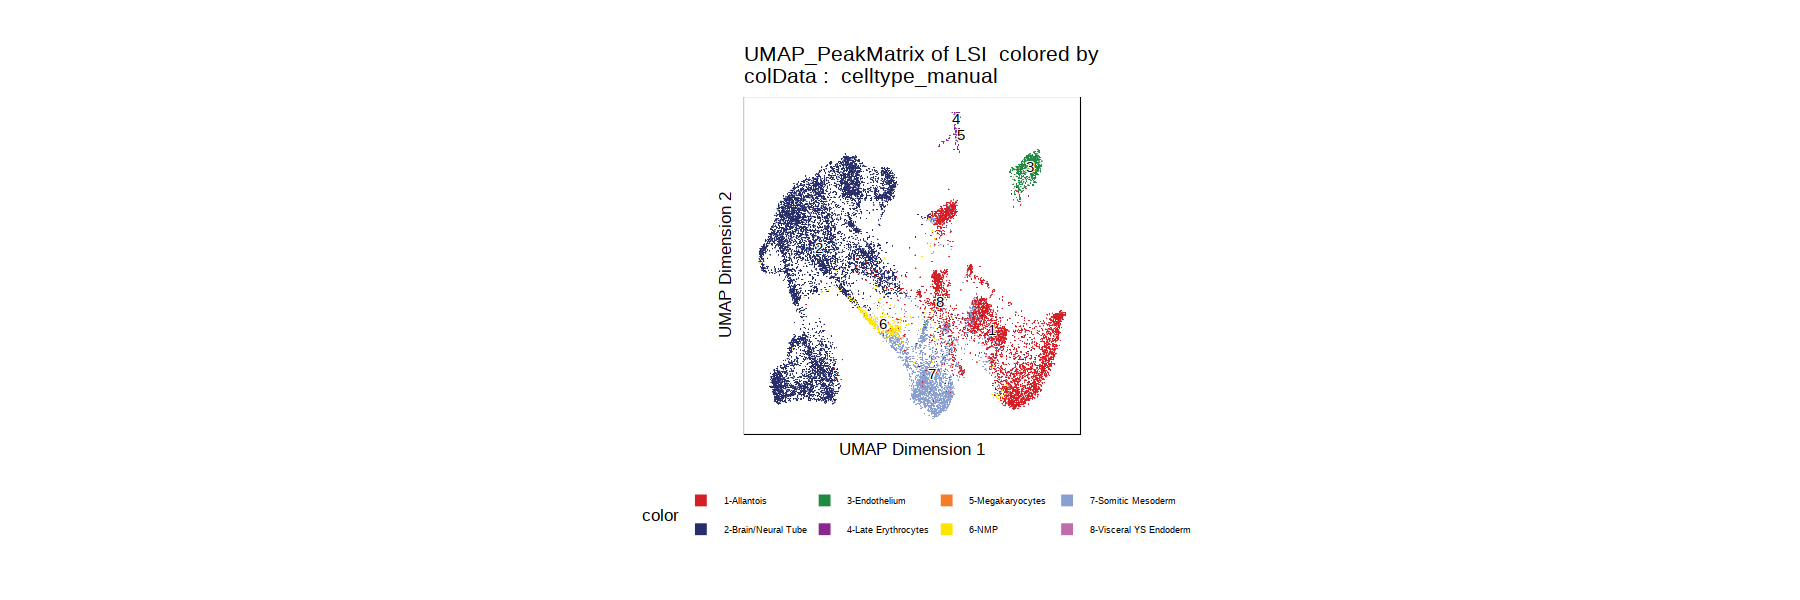

In [97]:
dim_redu(40, 45000)

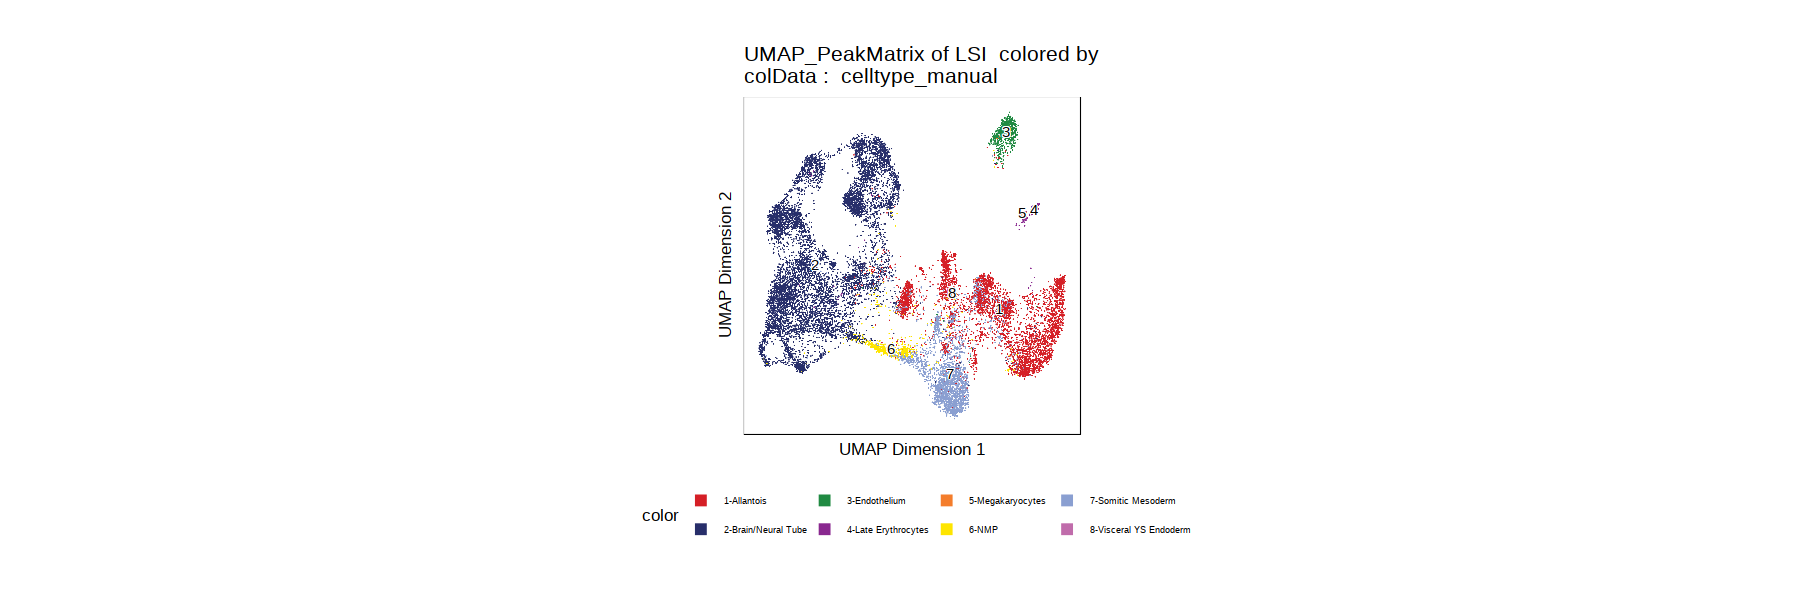

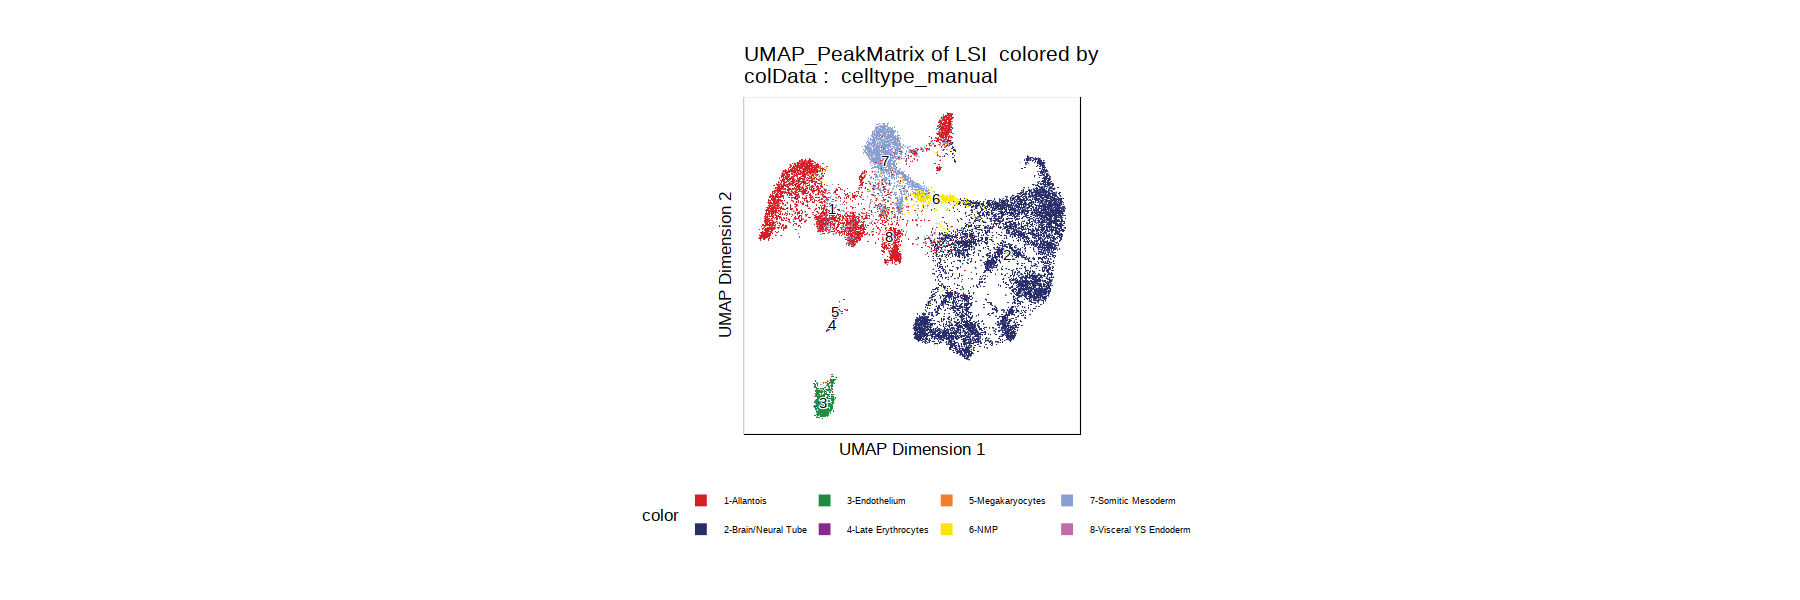

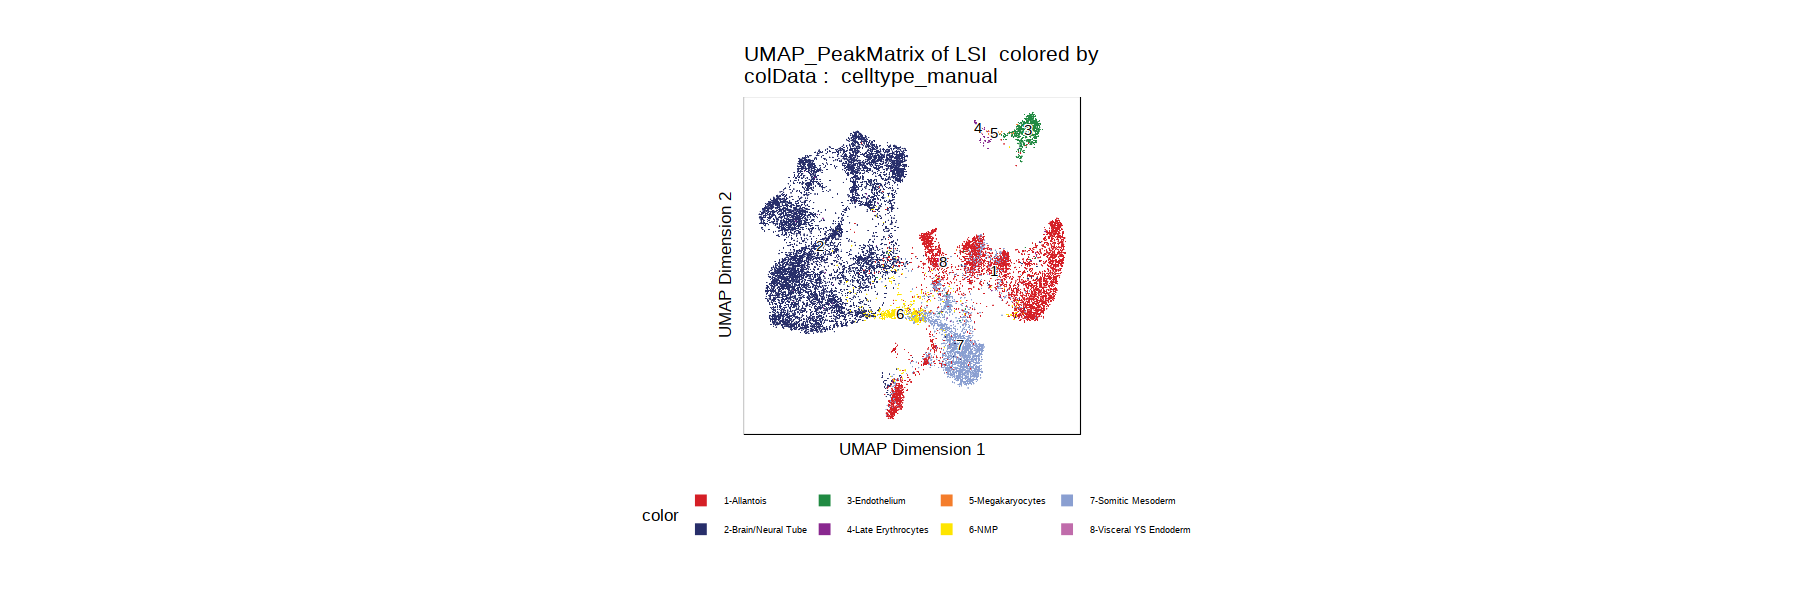

In [94]:
dim_redu(35, 45000)
dim_redu(35, 60000)
dim_redu(25, 60000)

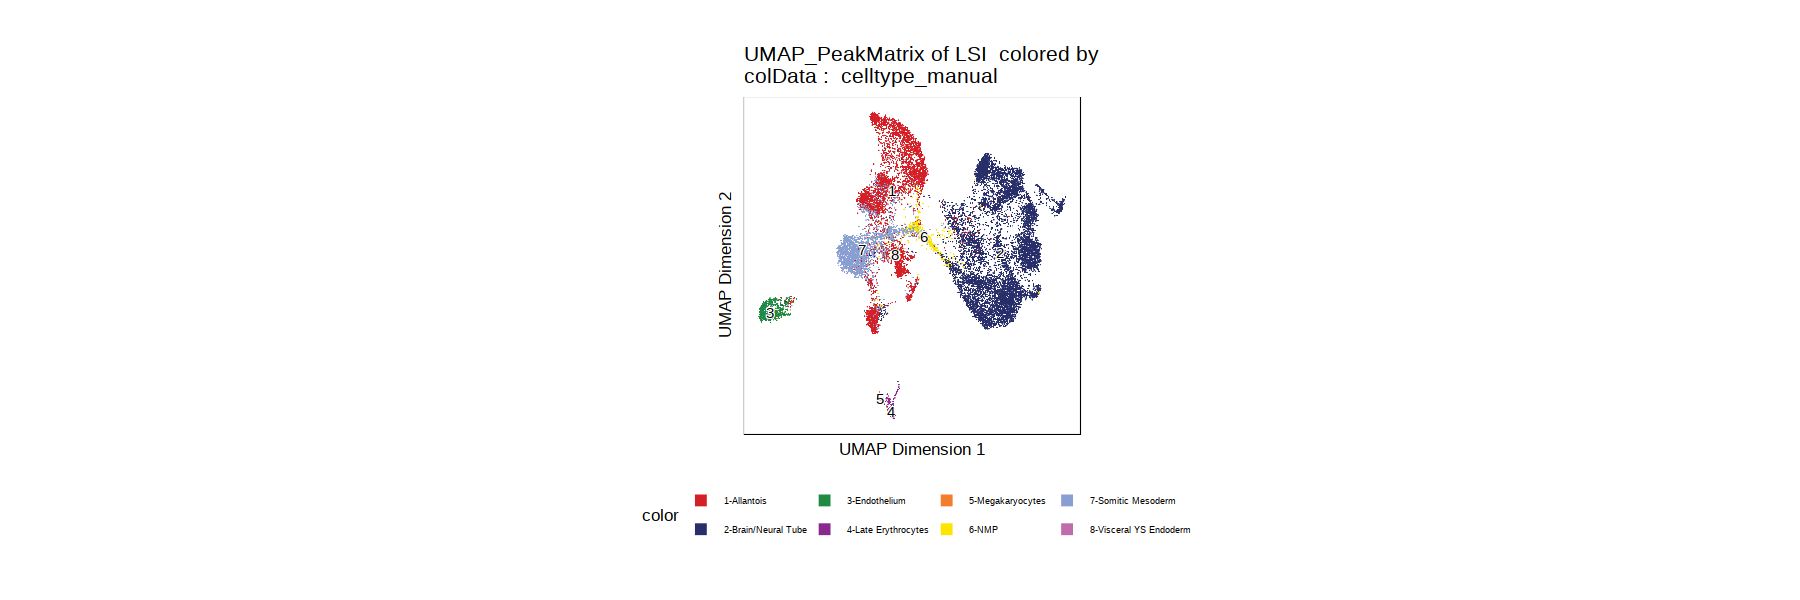

In [17]:
# Same on old peak matrix
dim_redu(35, 45000)

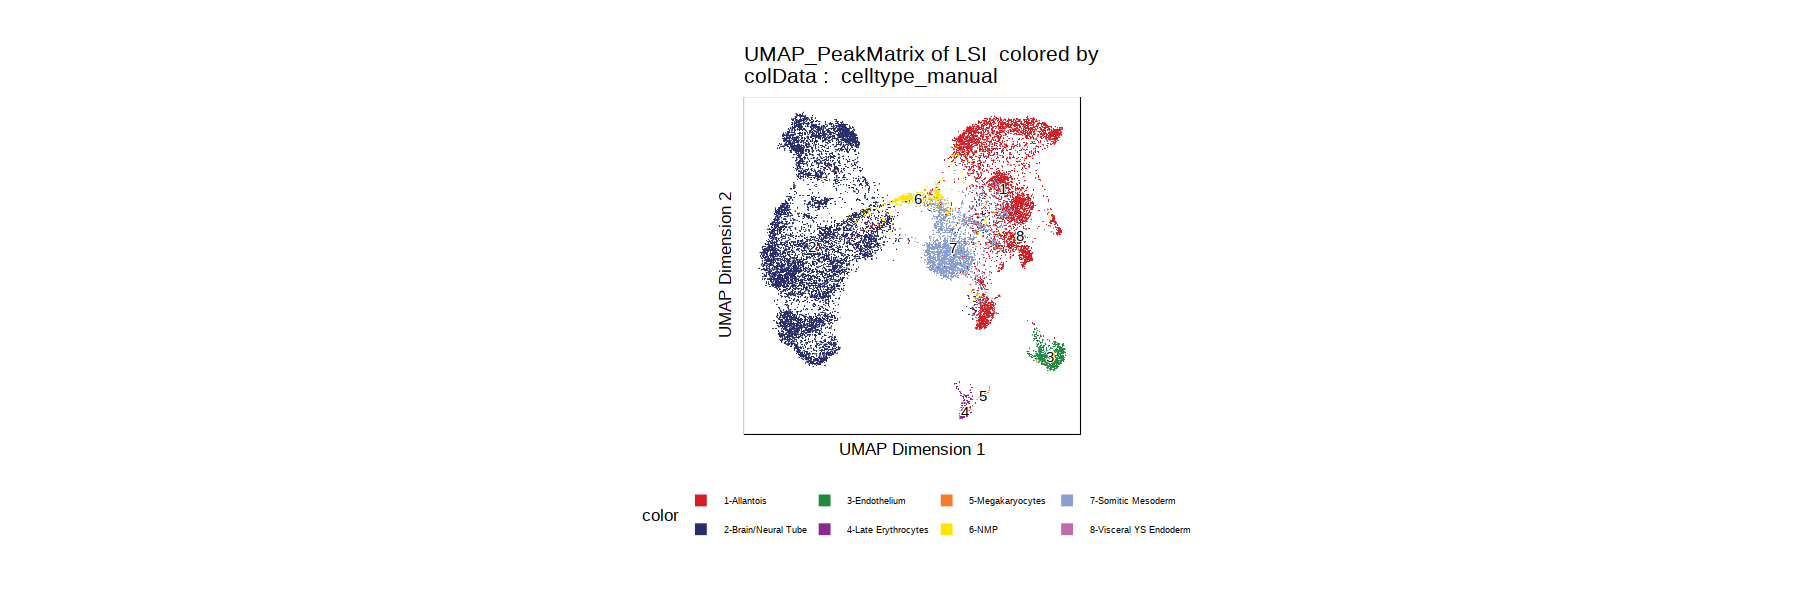

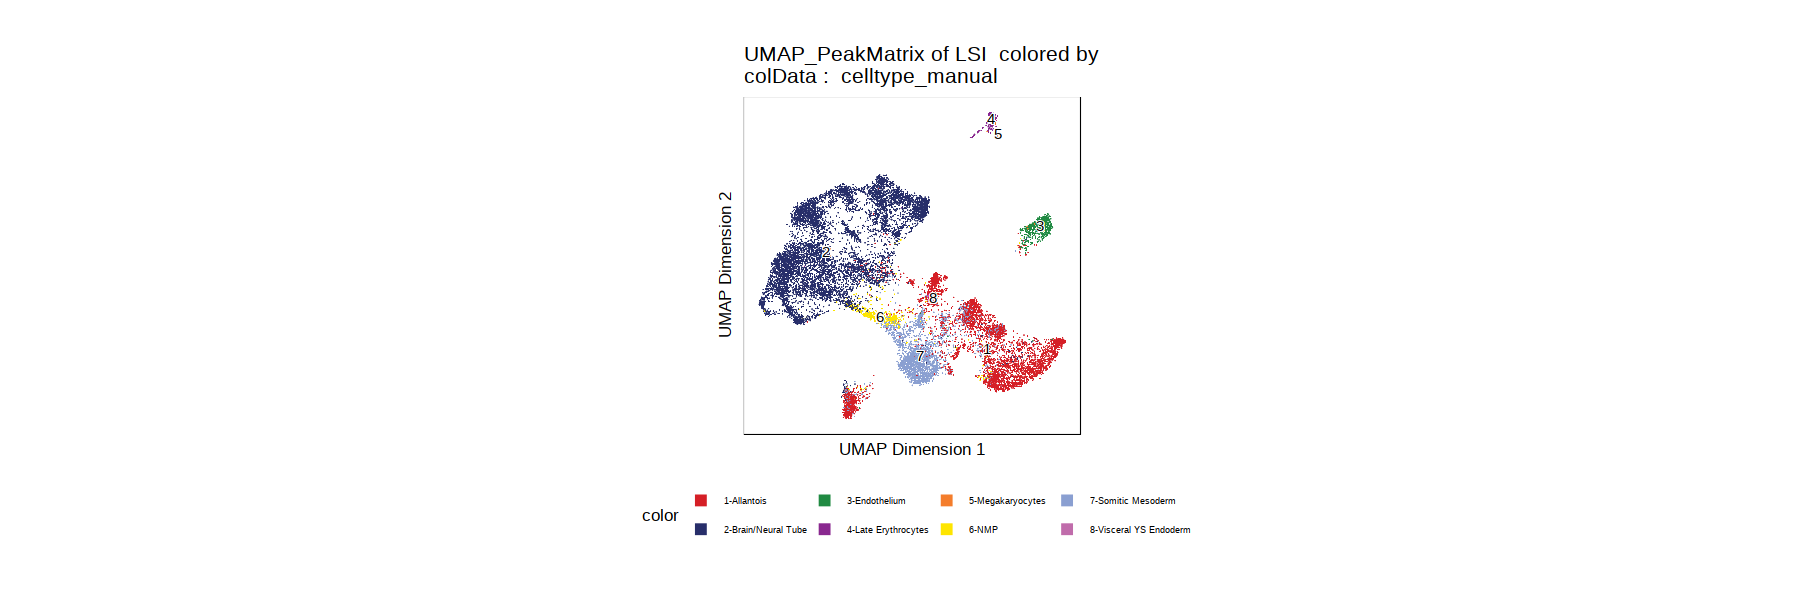

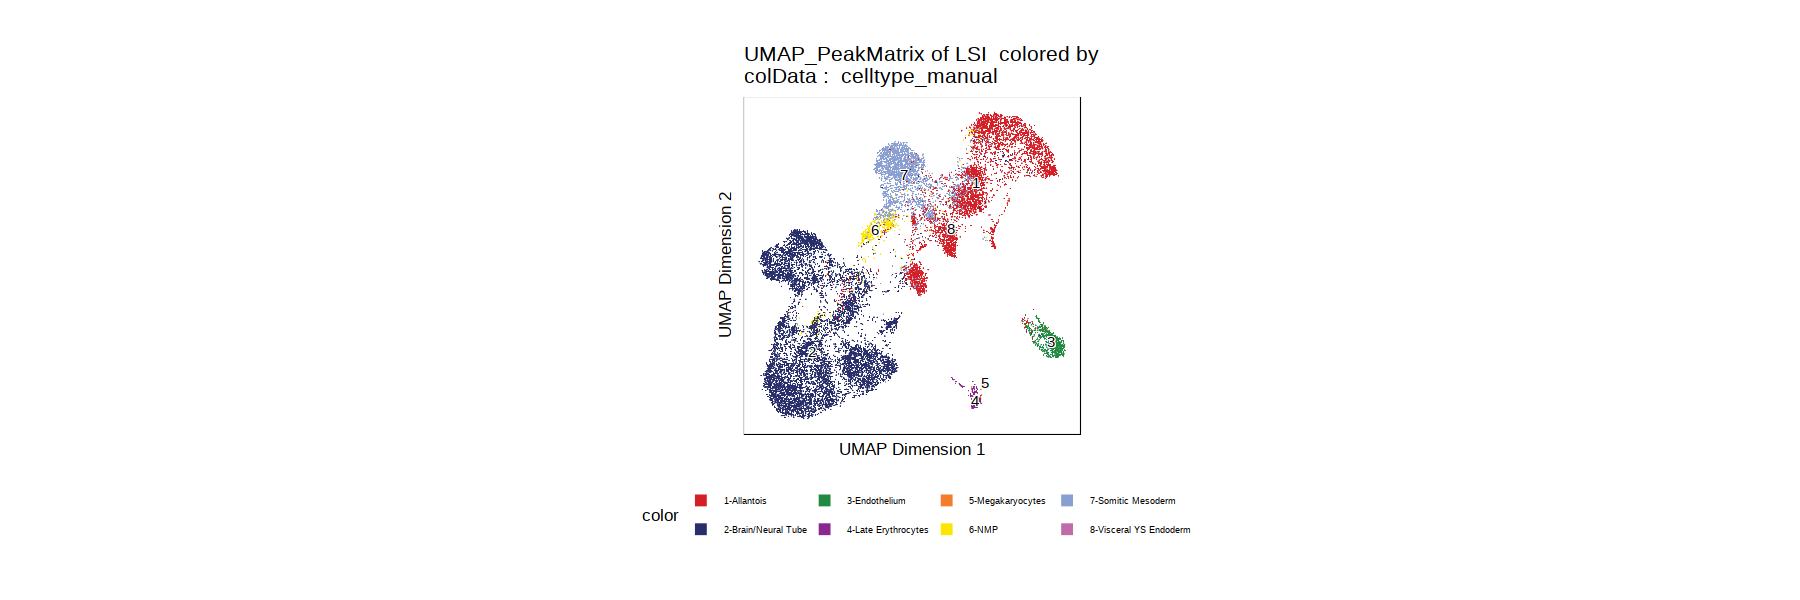

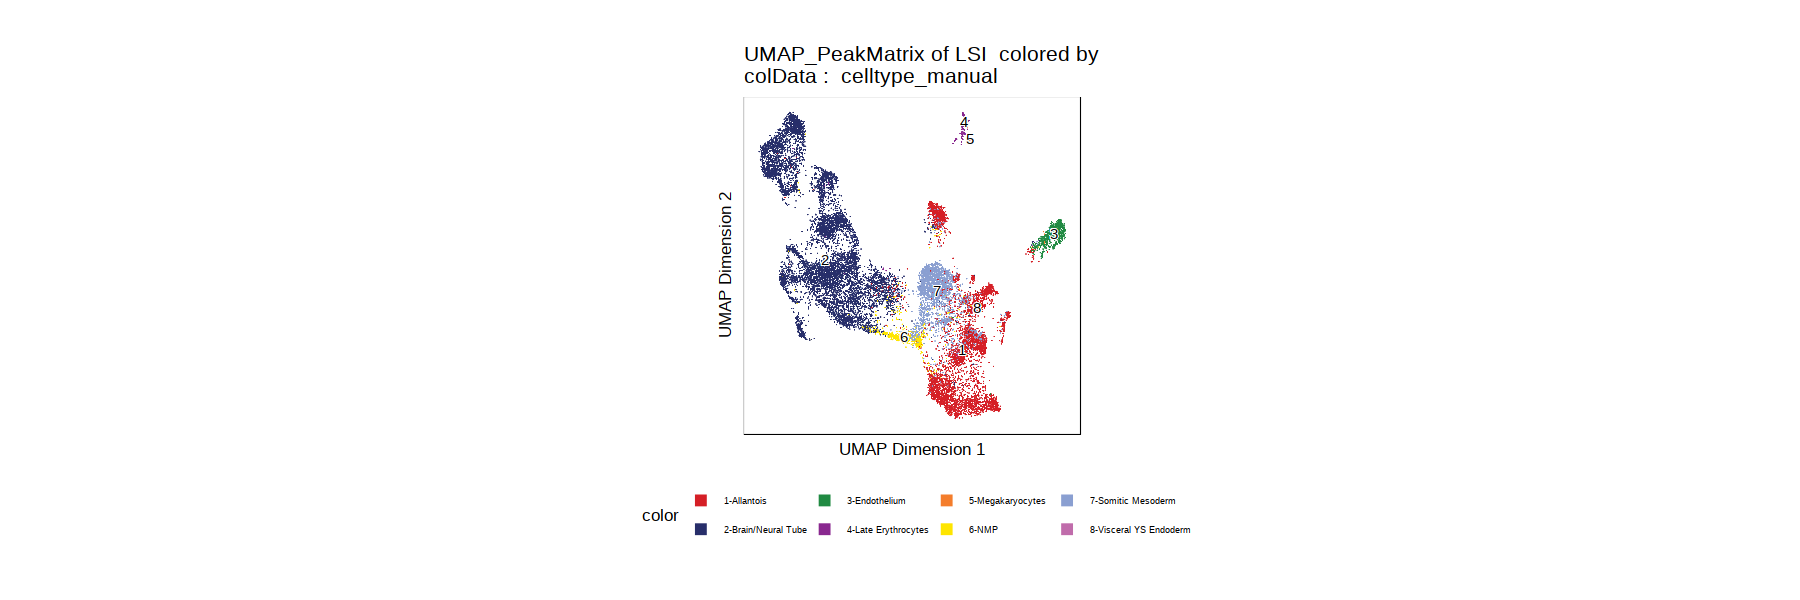

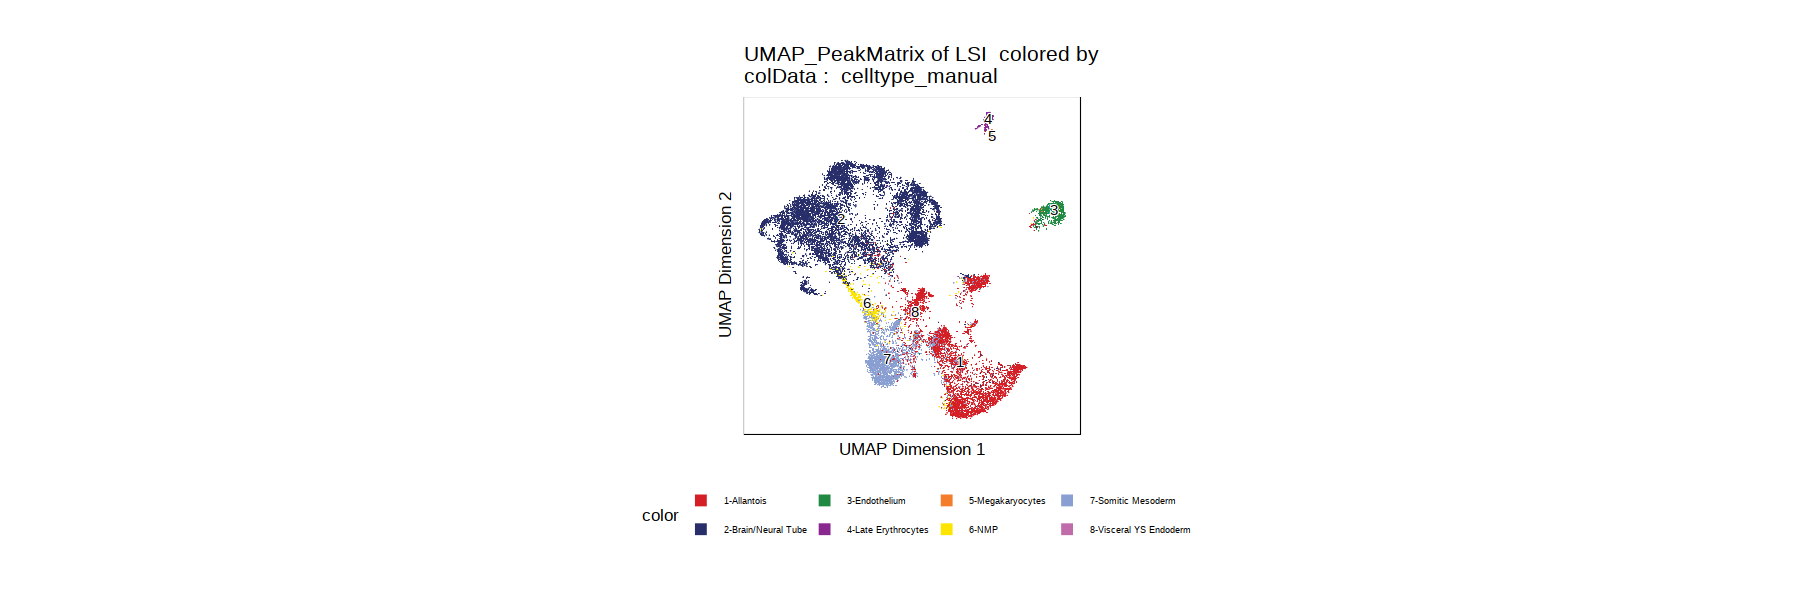

In [18]:
dim_redu(25, 45000)
dim_redu(45, 45000)

dim_redu(25, 55000)
dim_redu(35, 55000)
dim_redu(45, 55000)

# see if this also works with tilematrix

In [7]:
dim_redu = function(dims, features){
# Iterative LSI: two iterations
ArchRProject <- addIterativeLSI(
  ArchRProj = ArchRProject,
  useMatrix = 'TileMatrix', 
  name = 'LSI', 
  dimsToUse = 1:dims,
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = 2, 
  saveIterations = FALSE,
  varFeatures = features, 
  force = TRUE, verbose=FALSE
)

# Run UMAP
ArchRProject <- addUMAP(
  ArchRProj = ArchRProject, 
  reducedDims = 'LSI',
  name = "UMAP_PeakMatrix",
  metric = "cosine",
  nNeighbors = 25, 
  minDist = 0.3, 
  seed = 45,
  saveModel = FALSE,
  force = TRUE, verbose=FALSE
)

p = plotEmbedding(ArchRProject, 
'UMAP_PeakMatrix', 
colorBy = "cellColData", 
name = 'celltype_manual')
    print(p)
}

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


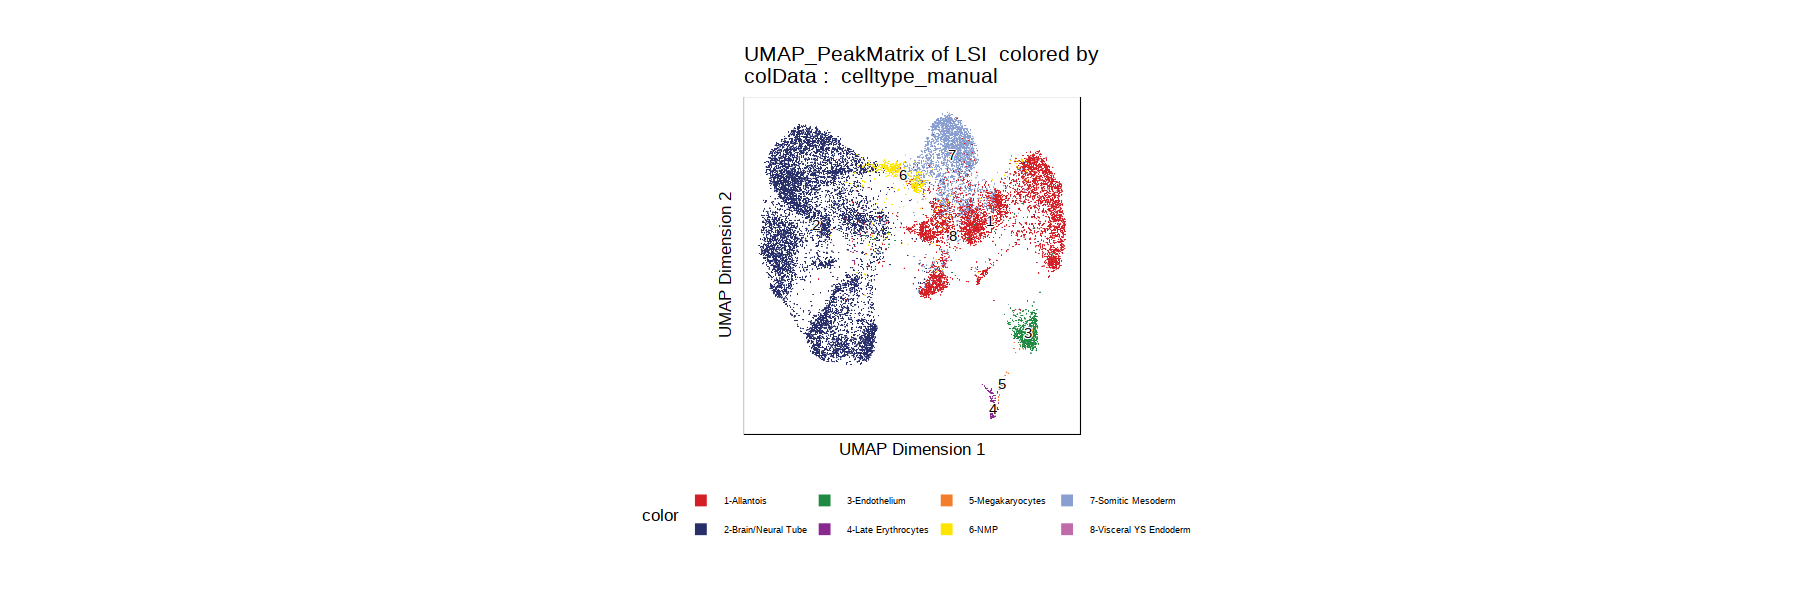

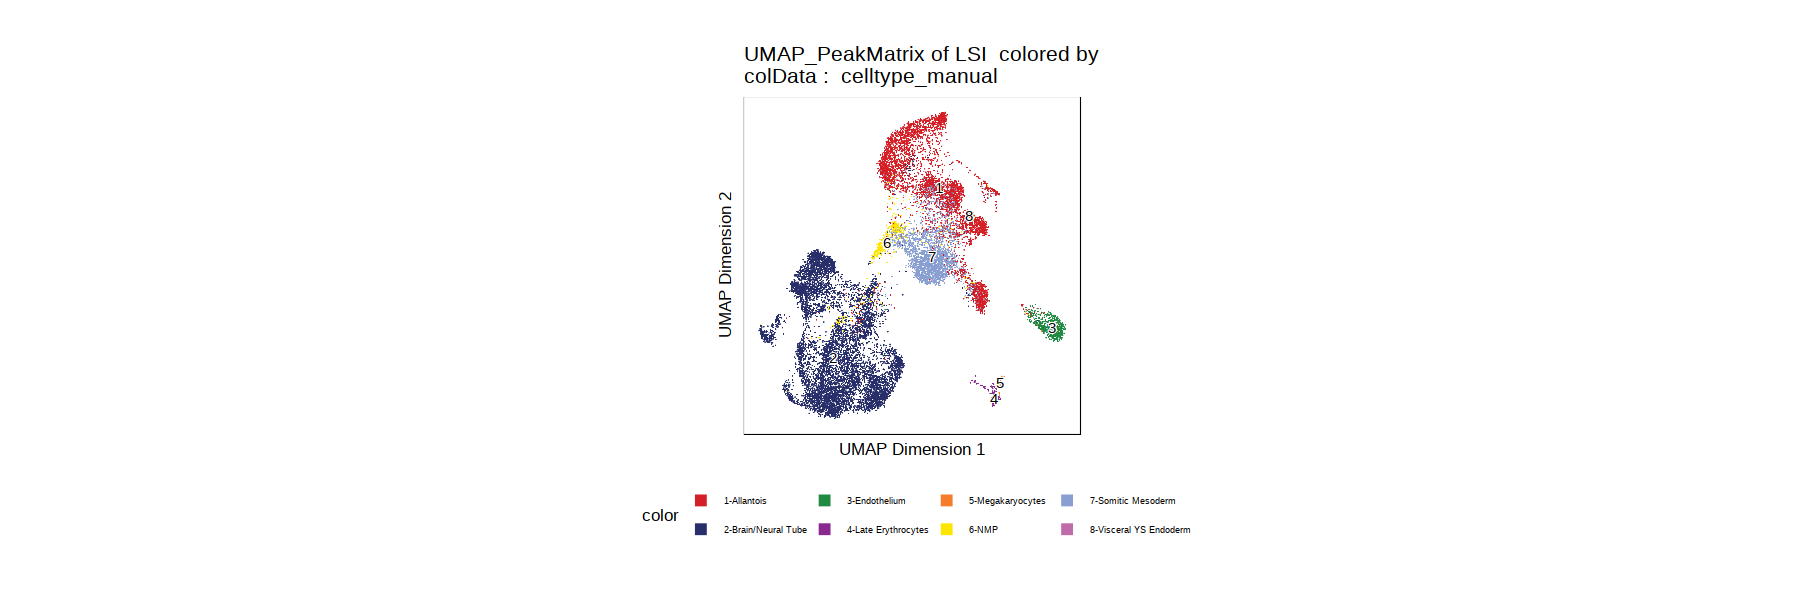

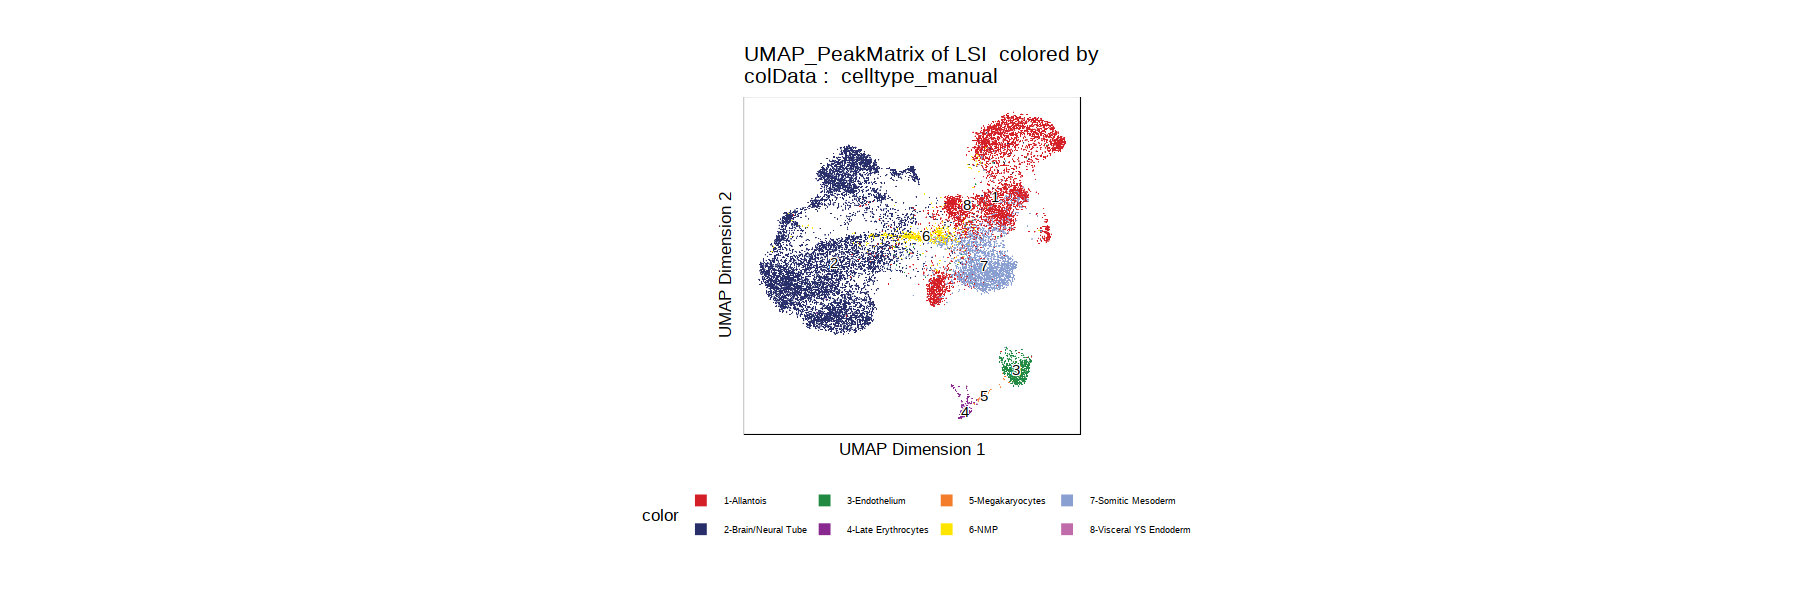

In [8]:
dim_redu(25, 45000)
dim_redu(35, 45000)
dim_redu(25, 35000)

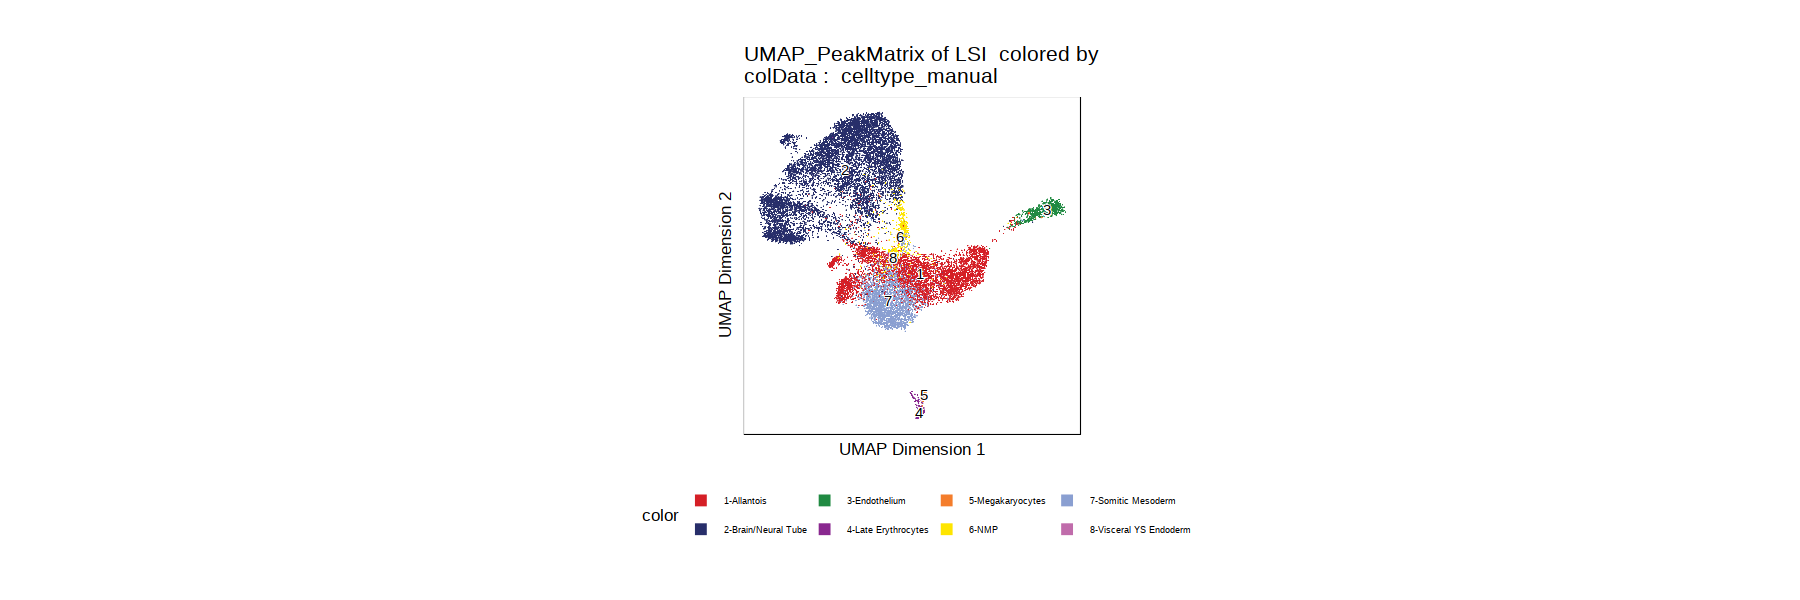

In [9]:
dim_redu(25, 25000)

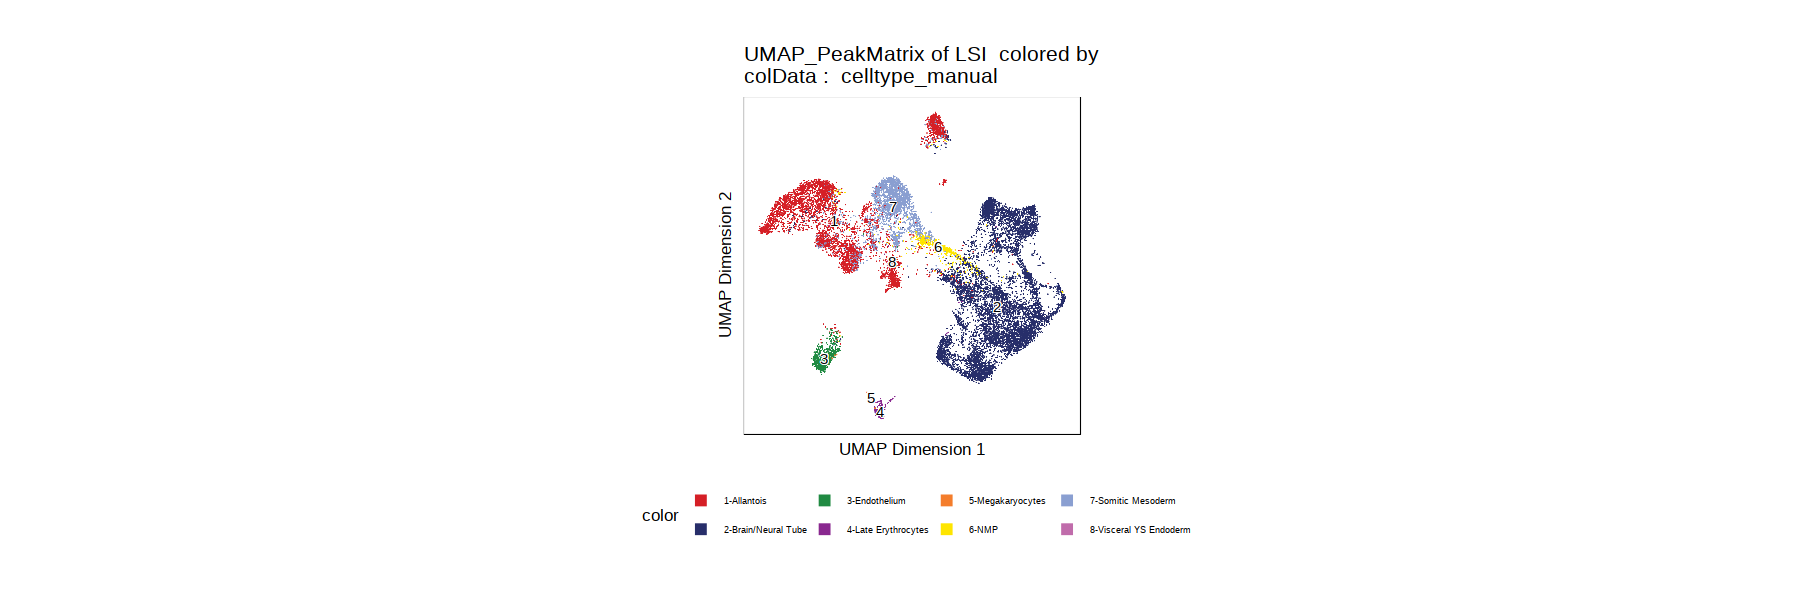

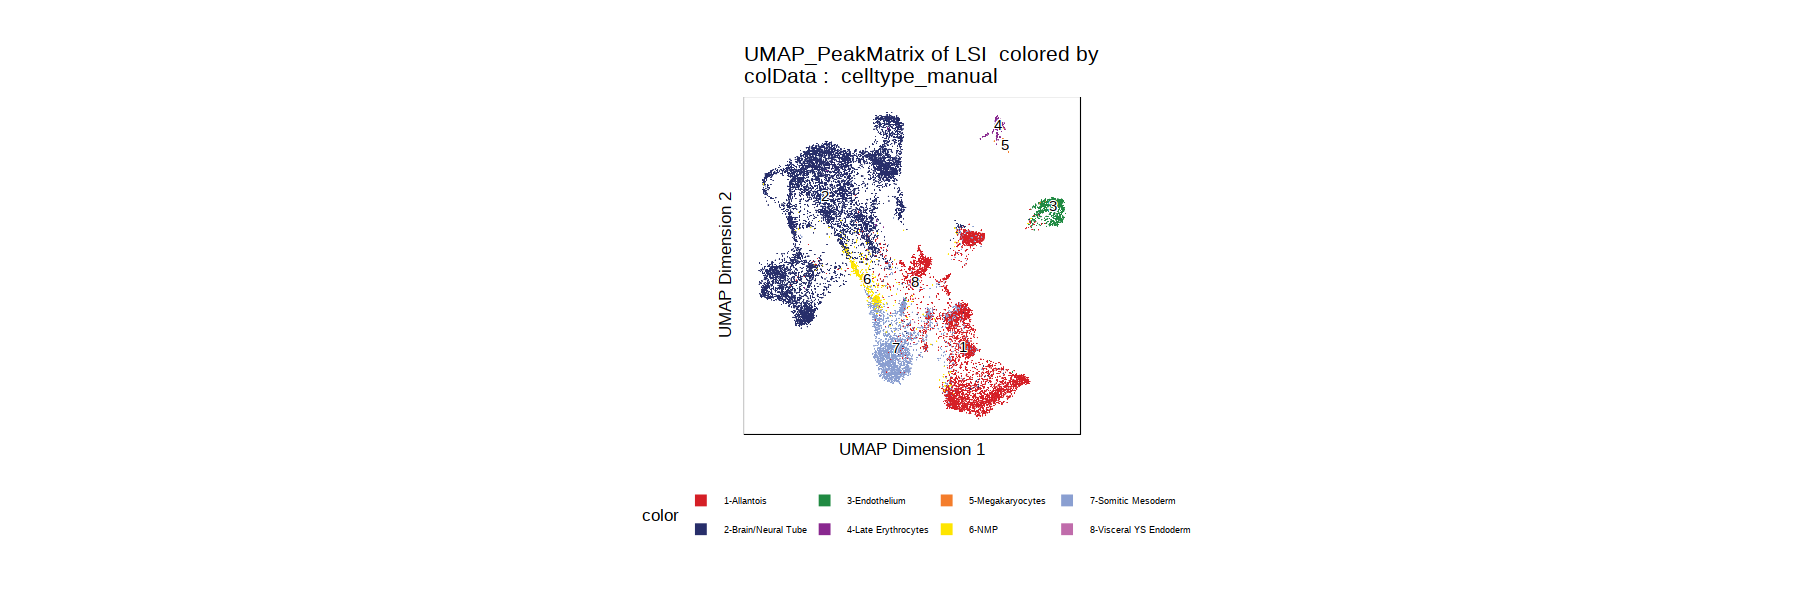

In [19]:
dim_redu(50, 45000)
dim_redu(50, 80000)

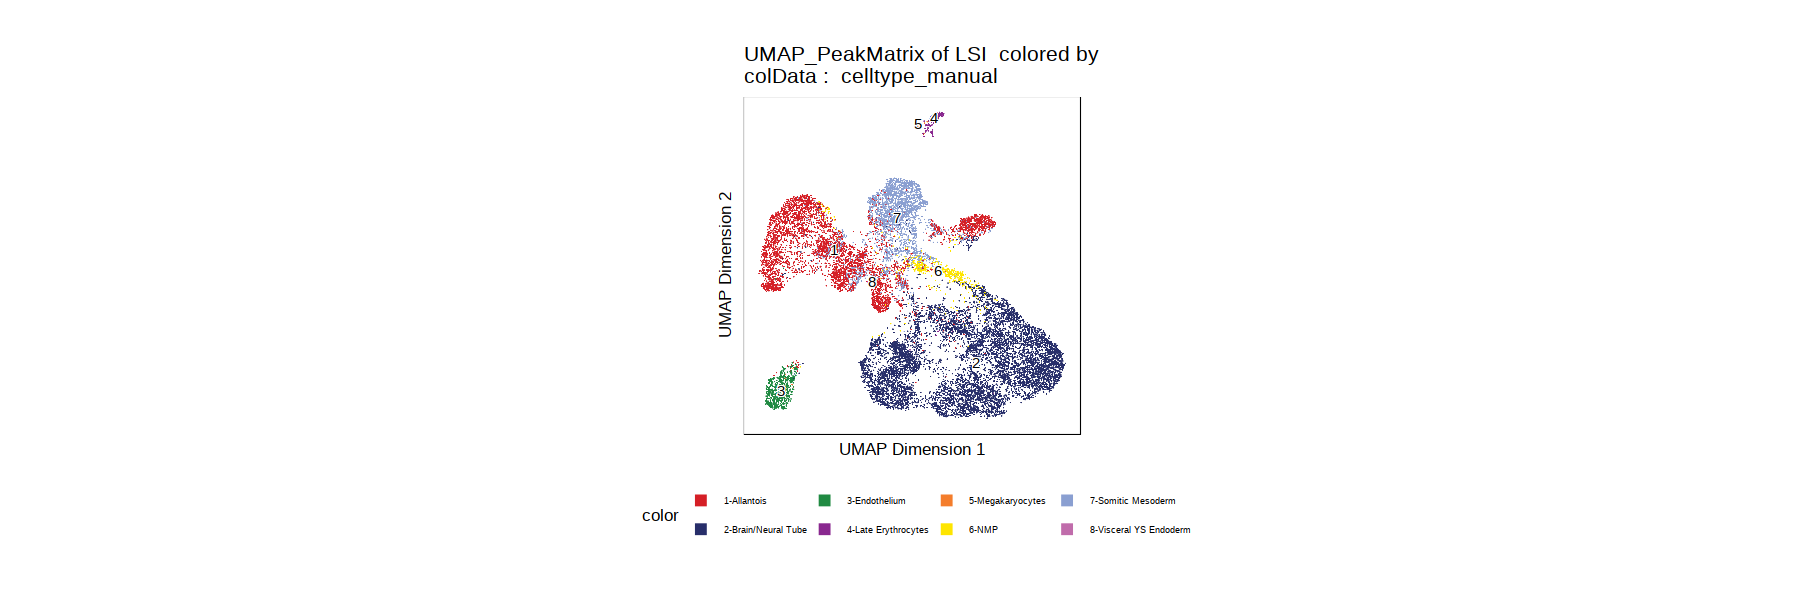

In [20]:
dim_redu(15, 45000)


In [77]:
ArchRProject@reducedDims$LSI$matSVD

,LSI1,LSI2,LSI3,LSI4,LSI5,LSI6,LSI7,LSI8,LSI9,LSI10,⋯,LSI21,LSI22,LSI23,LSI24,LSI25,LSI26,LSI27,LSI28,LSI29,LSI30
rabbit_BGRGP5#AAACGAAAGATCGAGC-1,-57.06512,-10.3529257,-4.3257358,1.9736954,4.85261363,1.59950317,3.7034784,-5.50319411,9.6416082,-0.816241321,⋯,-1.3149927,4.13702759,-0.18050383,1.3275720,0.467532737,1.19159621,5.22886926,2.2858959,1.5207120,3.26364417
rabbit_BGRGP5#AAACGAACAGATACAA-1,-49.35148,9.9116959,-8.0458857,4.1789992,7.63546714,2.41186927,-3.2294219,-1.95941534,-1.5272677,4.422423796,⋯,-0.5865215,-2.89050206,1.07630889,-5.9964418,-3.810698645,-1.40832943,-4.29505023,-4.0882391,-1.8904026,-4.48700644
rabbit_BGRGP5#AAACGAACATCGACCG-1,-53.56457,1.7005623,4.9707236,2.8911780,2.42418798,-3.79699874,4.6585940,-3.97087980,2.8283024,7.269503506,⋯,1.5840659,-0.79636922,1.64295164,0.8838453,-6.119260662,3.22476548,0.59840676,-4.2730149,-1.8562304,-1.74215927
rabbit_BGRGP5#AAACGAAGTACCTATG-1,-40.66066,11.7907507,-5.0351497,5.8322375,-3.83185811,-0.66164588,5.0009030,0.13599956,1.7917317,2.775387843,⋯,1.1220201,2.18091849,0.40084068,-1.5851070,-5.370694266,-0.64191740,1.67746439,3.8456819,0.9429479,-2.90209171
rabbit_BGRGP5#AAACGAAGTATGCTAC-1,-54.00457,0.2803335,2.0048044,4.8361000,0.77088129,0.65702968,-5.5374501,0.06186929,-0.6921938,-4.116992503,⋯,0.9854452,1.44369455,1.86604242,-1.4774786,-2.526088547,0.68451996,2.78295079,-1.5598579,-0.9626979,1.34140811
rabbit_BGRGP5#AAACGAAGTCAGAAGC-1,-51.47948,12.9740478,-2.4602479,6.1405804,6.86968750,0.02576640,-6.9872467,-3.12081641,-2.8243496,6.999455156,⋯,1.6421475,-3.65043395,-1.81432001,1.2319184,1.334794979,-4.47313774,-2.25737201,-8.5130540,-2.7937340,-0.95780741
rabbit_BGRGP5#AAACGAAGTGCTGTGC-1,-62.36443,21.2630654,-4.8803642,0.3949235,-6.65483816,-4.35276849,-8.5071805,4.25255246,-1.8260726,1.193592617,⋯,-2.8414997,-3.71118556,-2.51788710,3.4135421,-1.733009903,1.04529603,0.33620955,5.9262811,0.5440474,1.61283056
rabbit_BGRGP5#AAACGAAGTGTCGTGC-1,-93.30574,-0.5422143,-2.7403242,-2.5134638,-11.80675614,1.75497495,4.0546108,-4.87189524,-0.2980713,-2.567501678,⋯,2.5367218,1.62754940,2.90642236,3.1045835,3.192870886,-3.50226682,-2.62593289,-0.8293965,1.4027836,3.27072926
rabbit_BGRGP5#AAACGAAGTTACTACG-1,-67.87587,-3.0134018,12.6624256,6.4596701,1.17665884,2.36257852,11.1869713,-0.50567883,4.3812441,-0.961899712,⋯,3.0476096,1.67338548,1.10977767,6.4253811,0.006130291,-1.94708007,-1.06444915,-3.6834028,-0.1586012,-5.04594767
rabbit_BGRGP5#AAACGAATCGGTTCCT-1,-83.60735,15.2860160,-0.6451513,4.9437381,-7.01470008,-0.04983542,2.5922350,5.96504757,-0.1596547,-1.092083896,⋯,-3.9377874,-5.43184772,4.08777457,0.3752592,-0.429561745,1.57212558,2.60908232,5.2398812,2.7266673,2.37491051


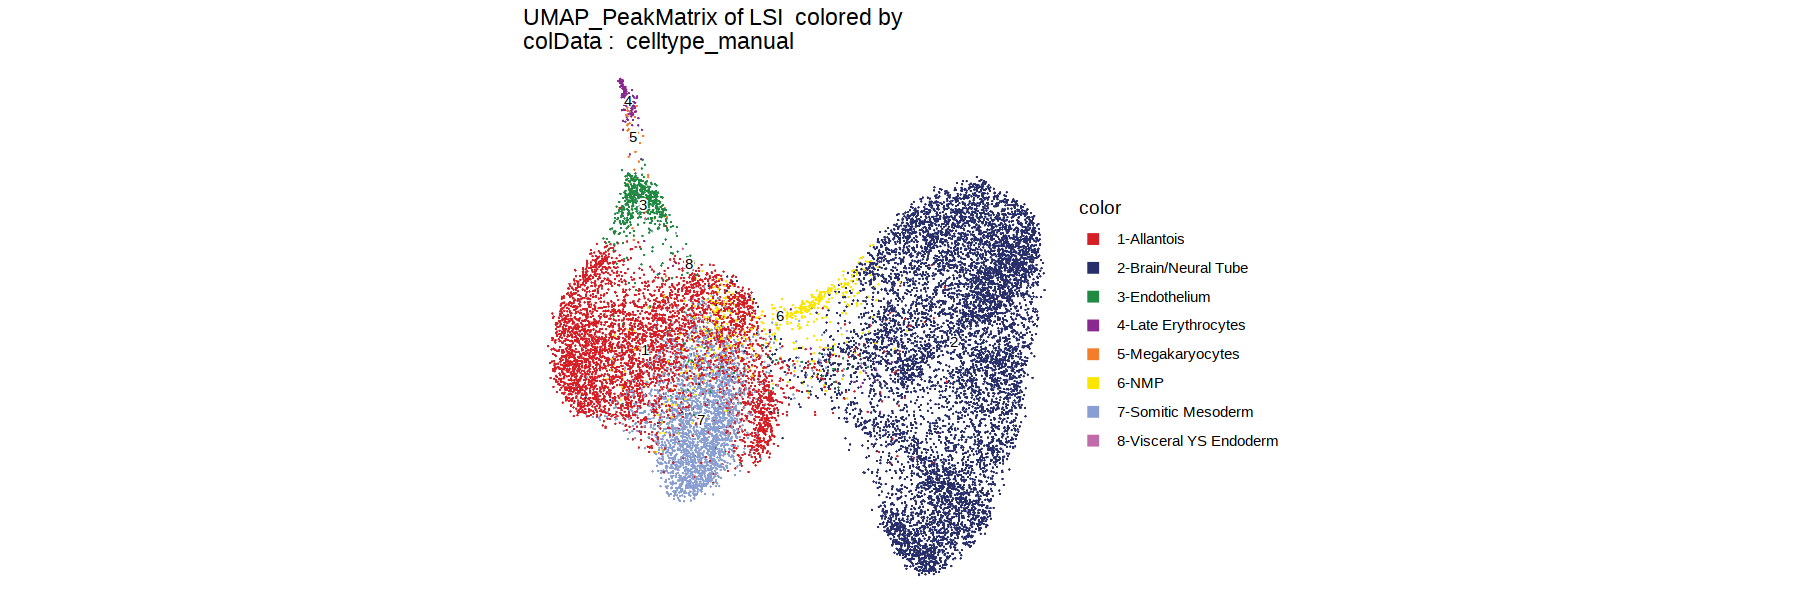

In [74]:
p + theme_void()

In [159]:
stage = 'GD9'

In [160]:
    ArchRProject_stage = ArchRProject[ArchRProject@cellColData[ArchRProject@cellColData$stage_mapping == stage,]$cell, ]
###########################
    ## Latent Semantic Index ##
    ###########################




Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [161]:
nrow(ArchRProject_stage@cellColData)

[1] 18238

In [57]:
ArchRProject_stage@cellColData$coverages = c(rep('A', 4500), rep('B', 9954-4500))

In [162]:
args$group_by = 'stage_mapping'
args$pathToMacs2 = findMacs2()
args$pvalue_cutoff = 0.001
args$extend_summits = 300

Searching For MACS2..

Found with $path!



In [163]:
addArchRThreads(threads = 12) 

Setting default number of Parallel threads to 12.



In [164]:
ArchRProject_stage <- addGroupCoverages(ArchRProject_stage, 
  groupBy = args$group_by,
  useLabels = TRUE,
  minCells = 40,
  maxCells = 500,
  force = TRUE
)

In [165]:

ArchRProject_stage <- addReproduciblePeakSet(
  ArchRProj = ArchRProject_stage, 
  groupBy = args$group_by, 
  peakMethod = "Macs2",
  excludeChr = c("chrM", "chrY"),
  pathToMacs2 = args$pathToMacs2,
  genomeSize = 2.7e9, # This argument is needed for the non-standard genome
  cutOff = args$pvalue_cutoff,
  extendSummits = args$extend_summits,
  plot = FALSE,
  force = TRUE
)

    Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
GD9   GD9  18238       2500           5  500  500   150000


Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
“GRanges object contains 3 out-of-bound ranges located on sequences
  chr12, chr13, and chr16. Note that ranges located on a sequence whose
  length is unknown (NA) or on a circular sequence are not considered
  out-of-bound (use seqlengths() and isCircular() to get the lengths and
  circularity flags of the underlying sequences). You can use trim() to
  trim these ranges. See ?`trim,GenomicRanges-method` for more
  information.”
Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
“GRanges object contains 3 out-of-bound ranges located on sequences
  chr12, chr13, and chr16. Note that ranges located on a sequence whose
  length is unknown (NA) or on a circular sequence are not considered
  out-of-bound (use seqlengths() and isCircular() to get the lengths and
  circularity flags of the underlying sequences). You can use trim() to
  trim these ranges. See ?`trim,GenomicRanges-method` for more
  in

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/Project/PeakCalls/GD9-reproduciblePeaks.gr.rds"


Converged after 1 iterations!



In [166]:
ArchRProject_stage <- addPeakMatrix(ArchRProject_stage)

Overriding previous entry for ReadsInPeaks

Overriding previous entry for FRIP



In [167]:
    # Iterative LSI: two iterations
    ArchRProject_stage <- addIterativeLSI(
      ArchRProj = ArchRProject_stage,
      useMatrix = 'PeakMatrix', 
      name = 'LSI', 
      dimsToUse = 1:20,
      firstSelection = "Top",
      depthCol = "nFrags",
      iterations = 2, 
      saveIterations = FALSE,
      varFeatures = 3000, 
      force = TRUE
    )

Checking Inputs...



ERROR: Error in FUN(X[[i]], ...): rowSums lengths do not match in ArrowFiles for a seqname!


In [168]:
peakMatrix = getMatrixFromProject(
  ArchRProj = ArchRProject_stage,
  useMatrix = "PeakMatrix",
  useSeqnames = NULL,
  verbose = TRUE,
  binarize = FALSE,
  threads = getArchRThreads(),
  logFile = createLogFile("getMatrixFromProject")
)

In [179]:
matrix = peakMatrix@assays@data$PeakMatrix

In [170]:
library(Matrix)
library(matrixStats)

In [171]:
vars = data.frame(idx = 1:nrow(matrix), var = rowVars(matrix, na.rm = TRUE)) %>% data.table

In [172]:
nrow(vars)

[1] 108370

In [176]:
top_var = vars[order(-var),] %>% top_n(5000) %>% .$idx

Selecting by var



In [180]:
matrix = matrix[top_var,]

In [181]:
matrix[1:10, 1:10]

   [[ suppressing 10 column names ‘rabbit_BGRGP6#AAACTCGGTTCCCTTG-1’, ‘rabbit_BGRGP6#ACAAACCAGGAGTACC-1’, ‘rabbit_BGRGP6#GTTGGGCGTATTCACG-1’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                         
 [1,] 4 4 4 4 4 4 4 4 . 4
 [2,] 4 4 4 4 4 4 4 4 2 4
 [3,] 4 . 3 3 . 2 4 2 2 1
 [4,] 4 4 4 4 4 1 2 2 . 1
 [5,] 4 4 4 4 4 3 4 4 3 4
 [6,] 4 4 4 4 4 4 4 2 4 4
 [7,] 4 3 1 4 4 4 4 4 4 4
 [8,] 4 2 2 4 4 4 . 4 4 4
 [9,] 4 4 4 3 4 4 4 3 4 .
[10,] . 4 2 4 4 . . 4 4 .

In [182]:
pca = prcomp(t(matrix), center=TRUE, scale=TRUE)

In [183]:
pca = pca$x

In [184]:
pca = pca[,1:50]

In [185]:
library(uwot)

In [186]:
umap = umap(pca)

In [187]:
umap = umap %>% data.table %>% setnames(c('umap1','umap2'))

In [188]:

   # Run UMAP
    ArchRProject_stage <- addUMAP(
      ArchRProj = ArchRProject_stage, 
      reducedDims = 'LSI',
      name = "UMAP_PeakMatrix",
      metric = "cosine",
      nNeighbors = 25, 
      minDist = 0.3, 
      seed = 45,
      saveModel = FALSE,
      force = TRUE
    )

p = plotEmbedding(ArchRProject_stage, 
    'UMAP_PeakMatrix', 
    colorBy = "cellColData", 
    name = 'celltype_manual')
    print(p)

ERROR: Error in getReducedDims(ArchRProj = ArchRProj, reducedDims = reducedDims, : Reduced dimensions not in computed reduceDims, Current ones are : TileMatrix,PeakMatrix
